# Figure 3

This notebook examines how mutation-only fitness decay recovers ruggedness on binary NK landscapes. It generates start-resolved decay trajectories, compares fitted and analytical ruggedness, tests sensitivity to experimental sampling parameters, and assembles the individual and complete Figure 3 panels.

## Setup

Load the simulation, decay-fitting, ruggedness-metric, serialisation, and plotting tools used throughout the notebook. The overwrite flags control whether raw simulations and processed summaries are recomputed; `PLOT_ONLY` requires existing processed products and skips data generation.

Cached raw and processed products can be installed from the repository root with `python slide/download_zenodo_data.py`. The notebook can generate missing products when its overwrite and plot-only settings permit it.

In [20]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from collections.abc import Callable

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import numpy as np
from matplotlib.gridspec import GridSpec
from tqdm.auto import tqdm

from slide.data_generation import (
    nk_grid_pairs,
    ordered_unique_pairs,
    random_start,
    run_nk_start_averaged_diffusion,
)
from slide.direvo_functions import get_single_decay_rate, model_function
from slide.ruggedness_functions import (
    find_distance_to_closest_max,
    get_dirichlet_metric,
    get_mean_paths_to_max,
    get_nk_l_o_shape,
    get_spectral_entropy,
    landscape_r2,
    local_epistasis,
    roughness_to_slope,
)
from slide.utils import (
    FIGURE_BOX_STYLE,
    FIGURE_COLORS,
    FIGURE_LABEL_SIZE,
    FIGURE_LEGEND_SIZE,
    FIGURE_TICK_SIZE,
    FIGURE_TITLE_SIZE,
    PANEL_LETTER_SIZE,
    get_figures_dir,
    get_processed_data_dir,
    get_raw_data_dir,
    load_pickle,
    save_pickle,
)

OVERWRITE_RAW_PKL: bool = False
OVERWRITE_PROCESSED_PKL: bool = False
PLOT_ONLY: bool = True
SAVE_FIGURES: bool = True
SAVE_TYPE_LIST = ("pdf", "png", "eps")
PANEL_DPI = 350

RAW_DATA_DIR = get_raw_data_dir()
PROCESSED_DATA_DIR = get_processed_data_dir()
FIGURES_DIR = get_figures_dir()
for figure_type in SAVE_TYPE_LIST:
    (FIGURES_DIR / figure_type).mkdir(parents=True, exist_ok=True)

print(f"raw_data: {RAW_DATA_DIR}")
print(f"processed_data: {PROCESSED_DATA_DIR}")
print(f"figures: {FIGURES_DIR}")


def save_panel_figure(fig: plt.Figure, stem: str, *, bbox_inches: str = "tight") -> None:
    """Save a panel figure in each configured output format."""
    if not SAVE_FIGURES:
        return
    for figure_type in SAVE_TYPE_LIST:
        fig.savefig(FIGURES_DIR / figure_type / f"{stem}.{figure_type}", dpi=PANEL_DPI, bbox_inches=bbox_inches, pad_inches=0)


def add_panel_letter(ax: plt.Axes, letter: str) -> None:
    """Add the panel letter annotation used in the paper figures."""
    fig = ax.get_figure()
    ax.text(-0.16, 1.08, letter, transform=ax.transAxes + mtransforms.ScaledTranslation(-18/72, 8/72, fig.dpi_scale_trans), fontsize=PANEL_LETTER_SIZE, fontweight="bold", va="top", ha="left")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
raw_data: /home/idris/workspace_python/SLIDE/raw_data
processed_data: /home/idris/workspace_python/SLIDE/processed_data
figures: /home/idris/workspace_python/SLIDE/figures


## Files and Shared Processing Functions

Define the raw and processed payload paths and the functions used to convert start-resolved trajectories into decay summaries. For a starting genotype $\nu$, population replicates are averaged to estimate the mean-fitness trajectory $F_\mu(\nu)$. Squaring this trajectory gives its contribution to squared-fitness decay, and averaging over starting genotypes gives

$$G_\mu=\mathbb{E}_{\nu}\!\left[F_\mu(\nu)^2\right].$$

The shared functions also normalise curves, fit exponential decay rates, and load or save cached products without changing the raw simulation arrays.

In [21]:
RAW_FILES = {
    "nk_decay_grid": "figure3_nk_decay_grid_raw.pkl",
    "nk_popsize_accuracy": "figure3_nk_popsize_accuracy_raw.pkl",
    "nk_mutation_accuracy": "figure3_nk_mutation_accuracy_raw.pkl",
    "nk_start_count_accuracy": "figure3_nk_start_count_accuracy_raw.pkl",
}

PROCESSED_FILES = {
    "decay_examples": "figure3_decay_examples_processed.pkl",
    "ruggedness_accuracy": "figure3_ruggedness_accuracy_processed.pkl",
    "popsize_accuracy": "figure3_popsize_accuracy_processed.pkl",
    "mutation_accuracy": "figure3_mutation_accuracy_processed.pkl",
    "start_count_accuracy": "figure3_start_count_accuracy_processed.pkl",
    "metric_comparison": "figure3_metric_comparison_processed.pkl",
}


def raw_path(key: str) -> Path:
    """Return the raw-data path for a Figure 3 payload key.

    Parameters:
    - key: str
        Figure 3 raw payload key in ``RAW_FILES``.

    Returns:
    - Path
        Full path to the requested raw payload.
    """

    return RAW_DATA_DIR / RAW_FILES[key]


def processed_path(key: str) -> Path:
    """Return the processed-data path for a Figure 3 payload key.

    Parameters:
    - key: str
        Figure 3 processed payload key in ``PROCESSED_FILES``.

    Returns:
    - Path
        Full path to the requested processed payload.
    """

    return PROCESSED_DATA_DIR / PROCESSED_FILES[key]


def load_or_build_processed(key: str, builder: Callable[[], dict[str, object]]) -> dict[str, object]:
    """Load a processed Figure 3 payload or build and save it.

    Parameters:
    - key: str
        Figure 3 processed payload key in ``PROCESSED_FILES``.
    - builder: Callable[[], dict[str, object]]
        Function that builds the processed payload when rebuilding is allowed.

    Returns:
    - dict[str, object]
        Processed payload for plotting or downstream processing.
    """
    path = processed_path(key)
    if path.exists() and (PLOT_ONLY or not OVERWRITE_PROCESSED_PKL):
        print(f"{path} already exists. Loading existing processed payload.")
        return load_pickle(path)
    if PLOT_ONLY:
        raise FileNotFoundError(f"PLOT_ONLY=True requires processed payload {path}")
    payload = builder()
    save_pickle(payload, path)
    return payload


def start_curves_to_gmu(start_curves: np.ndarray, *, average_axis: int | tuple[int, ...] = -2) -> np.ndarray:
    """Convert start-level `F_mu` curves to `G_mu` by squaring before averaging starts."""
    return np.square(np.asarray(start_curves, dtype=float)).mean(axis=average_axis)


def normalize_curve(curve: np.ndarray) -> np.ndarray:
    """Normalize one decay curve by its initial value for fitting and plotting."""
    curve = np.asarray(curve, dtype=float)
    return curve / curve[0]


def fit_gmu_decay(g_mu: np.ndarray, *, mutation_rate: float, num_steps: int) -> tuple[float, float]:
    """Fit the squared-decay model and return `(rho_2_fit, fitted_constant)`.

    Since `G_mu` follows `exp(-2 * mu * rho_2)`, the existing single-exponential fitter
    is called with `mut=2 * mutation_rate`. The returned rate is therefore directly on
    the `rho_2` scale used in the paper.
    """
    normalized = normalize_curve(g_mu)
    return get_single_decay_rate(normalized, mut=2 * mutation_rate, num_steps=num_steps)


def fitted_gmu_curve(g_mu: np.ndarray, *, mutation_rate: float) -> tuple[np.ndarray, float]:
    """Return the fitted normalized `G_mu` curve and fitted `rho_2` value."""
    x = np.arange(len(g_mu))
    rho_2_fit, constant = fit_gmu_decay(g_mu, mutation_rate=mutation_rate, num_steps=len(g_mu))
    fitted = model_function(x, rho_2_fit, constant, mut=2 * mutation_rate)
    return fitted, float(rho_2_fit)


def print_params(title: str, params: dict, path: Path) -> None:
    """Print a compact parameter block before long-running generation cells."""
    print(f"\n---\n{title}:")
    for key, value in params.items():
        print(f"  {key}: {value}")
    print(f"Save path: {path}")
    print("---\n")


## Raw Data — NK Decay Grid for Panels A, B, and F

Sample mutation-only diffusion on a grid of binary NK landscapes. For each $(N,K)$ pair, the code generates independent landscapes and starting genotypes, runs replicate populations under per-site mutation, and stores the population-replicate fitness trajectories separately. Averaging replicates at fixed start estimates $F_\mu(\nu)$; retaining the start axis is necessary both for local $F_\mu$ analyses and for the global $G_\mu$ average.

The parameter dictionary specifies the sampled $N$ and $K$ grid, alphabet size, number of landscapes, starts and population replicates, population size, mutation rate, trajectory length, and random seed. The processed products derived in this cell provide example decay curves and fitted ruggedness estimates across the NK grid.

In [22]:
grid_params = {
    "N_range": (10, 50),
    "num_grid_samples": 10,
    "A": 2,
    "mutation_rate": 0.5,
    "popsize": 2500,
    "num_landscapes": 25,
    "num_starts": 25,
    "num_reps_per_start": 5,
    "M": 25,
    "seed": 42,
    "start_policy": "random",
}
raw_pairs = nk_grid_pairs(grid_params["N_range"], grid_params["num_grid_samples"], K_start=0)
grid_params["nk_pairs"] = ordered_unique_pairs(raw_pairs)

nk_decay_grid_path = raw_path("nk_decay_grid")
print_params("Figure 3 new NK G_mu grid parameters", grid_params, nk_decay_grid_path)

if nk_decay_grid_path.exists() and (PLOT_ONLY or not OVERWRITE_RAW_PKL):
    print(f"{nk_decay_grid_path} already exists. Loading existing raw payload.")
    nk_decay_grid_payload = load_pickle(nk_decay_grid_path)
elif PLOT_ONLY:
    raise FileNotFoundError(f"PLOT_ONLY=True requires raw F_mu support payload {nk_decay_grid_path}")
else:
    pair_keys = jr.split(jr.PRNGKey(grid_params["seed"]), len(grid_params["nk_pairs"]))
    nk_decay_grid = []

    for pair_key, (N, K) in tqdm(list(zip(pair_keys, grid_params["nk_pairs"])), desc="Figure 3 new NK G_mu grid"):
        landscape_keys = jr.split(pair_key, grid_params["num_landscapes"])
        pair_results = []
        for landscape_index, landscape_key in enumerate(landscape_keys):
            start_keys = jr.split(jr.fold_in(landscape_key, 100_000 + landscape_index), grid_params["num_starts"])
            starts = np.asarray([
                random_start(start_key, n_sites=N, num_alleles=grid_params["A"])
                for start_key in start_keys
            ])
            start_curves = run_nk_start_averaged_diffusion(
                rng_key=landscape_key,
                n_sites=N,
                k=K,
                num_alleles=grid_params["A"],
                starts=starts,
                popsize=grid_params["popsize"],
                mutation_rate_per_site=grid_params["mutation_rate"] / N,
                num_reps_per_start=grid_params["num_reps_per_start"],
                num_steps=grid_params["M"],
            )
            pair_results.append(start_curves)
        nk_decay_grid.append(np.asarray(pair_results))

    nk_decay_grid_payload = {
        "data": np.asarray(nk_decay_grid),
        "params": grid_params,
        "metadata": {
            "description": "Start-resolved NK diffusion grid for Figure 3 new G_mu panels A, B, and E.",
            "paper_reference": "Figure 3A-B/E",
            "output_key": "figure3_nk_decay_grid",
            "filename": RAW_FILES["nk_decay_grid"],
            "shape": "nk_pair, landscape, start, generation",
        },
    }
    save_pickle(nk_decay_grid_payload, nk_decay_grid_path)

nk_decay_grid = np.asarray(nk_decay_grid_payload["data"], dtype=float)
nk_decay_params = nk_decay_grid_payload["params"]
nk_pairs = np.asarray(nk_decay_params["nk_pairs"], dtype=int)
print(f"Loaded NK decay grid shape: {nk_decay_grid.shape}")



---
Figure 3 new NK G_mu grid parameters:
  N_range: (10, 50)
  num_grid_samples: 10
  A: 2
  mutation_rate: 0.5
  popsize: 2500
  num_landscapes: 25
  num_starts: 25
  num_reps_per_start: 5
  M: 25
  seed: 42
  start_policy: random
  nk_pairs: [(50, 49), (50, 43), (50, 38), (50, 32), (50, 27), (50, 21), (50, 16), (50, 10), (50, 5), (50, 0), (45, 44), (45, 39), (45, 34), (45, 29), (45, 24), (45, 19), (45, 14), (45, 9), (45, 4), (45, 0), (41, 40), (41, 35), (41, 31), (41, 26), (41, 22), (41, 17), (41, 13), (41, 8), (41, 4), (41, 0), (36, 35), (36, 31), (36, 27), (36, 23), (36, 19), (36, 15), (36, 11), (36, 7), (36, 3), (36, 0), (32, 31), (32, 27), (32, 24), (32, 20), (32, 17), (32, 13), (32, 10), (32, 6), (32, 3), (32, 0), (27, 26), (27, 23), (27, 20), (27, 17), (27, 14), (27, 11), (27, 8), (27, 5), (27, 2), (27, 0), (23, 22), (23, 19), (23, 17), (23, 14), (23, 12), (23, 9), (23, 7), (23, 4), (23, 2), (23, 0), (18, 17), (18, 15), (18, 13), (18, 11), (18, 9), (18, 7), (18, 5), (18, 3), 

## Processing — Panel A Example Decay Curves

Select one smoother and one more rugged NK example. At every start, the code first averages the population replicates to obtain $F_\mu(\nu)$, then squares the result and averages over starts to obtain $G_\mu$. Each curve is normalised by its initial value and fitted with the notebook's exponential decay model so the sampled decay can be compared across landscapes.

In [23]:
PANEL_A_NK_EXAMPLES: dict[str, tuple[int, int]] = {
    "smooth": (50, 10),
    "rugged": (50, 43),
}
PANEL_A_LANDSCAPE_INDEX = 0

savepath_decay_examples_payload = processed_path("decay_examples")
if savepath_decay_examples_payload.exists() and (PLOT_ONLY or not OVERWRITE_PROCESSED_PKL):
    print(f"{savepath_decay_examples_payload} already exists. Loading existing processed payload.")
    decay_examples_payload = load_pickle(savepath_decay_examples_payload)
    decay_examples = decay_examples_payload["data"]
elif PLOT_ONLY:
    raise FileNotFoundError(f"PLOT_ONLY=True requires processed payload {savepath_decay_examples_payload}")
else:
    pair_to_index = {(int(N), int(K)): index for index, (N, K) in enumerate(nk_pairs)}
    decay_examples = {
        "smooth_rugged": [],
        "fitted_lines": [],
        "labels": [],
        "examples": {},
        "generations": np.arange(1, int(nk_decay_params["M"]) + 1),
    }

    for name, pair in PANEL_A_NK_EXAMPLES.items():
        if pair not in pair_to_index:
            raise ValueError(f"Requested Panel A pair {pair} is absent from nk_pairs: {nk_pairs.tolist()}")
        grid_index = pair_to_index[pair]
        N, K = pair
        rho_nk = (K + 1) / N
        start_curves = nk_decay_grid[grid_index, PANEL_A_LANDSCAPE_INDEX]
        g_mu = start_curves_to_gmu(start_curves, average_axis=0)
        normalized_g_mu = normalize_curve(g_mu)
        fitted_curve, rho_2_fit = fitted_gmu_curve(g_mu, mutation_rate=float(nk_decay_params["mutation_rate"]))
        label = rf"{name.title()}: $\rho_{{NK}}={rho_nk:.2f}$ ($K={K}$), $\rho_2^{{\mathrm{{fit}}}}={rho_2_fit:.2f}$"

        decay_examples["smooth_rugged"].append(normalized_g_mu)
        decay_examples["fitted_lines"].append(fitted_curve)
        decay_examples["labels"].append(label)
        decay_examples["examples"][name] = {
            "N": int(N),
            "K": int(K),
            "rho_NK": float(rho_nk),
            "rho_2_fit": float(rho_2_fit),
            "grid_index": int(grid_index),
            "landscape_index": int(PANEL_A_LANDSCAPE_INDEX),
            "num_starts": int(nk_decay_params["num_starts"]),
            "num_reps_per_start": int(nk_decay_params["num_reps_per_start"]),
            "legend_label": label,
        }

    decay_examples_payload = {
        "data": decay_examples,
        "params": {**nk_decay_params, "panel_a_examples": decay_examples["examples"]},
        "metadata": {
            "description": "Processed NK G_mu example decay curves for Figure 3 new Panel A.",
            "paper_reference": "Figure 3A",
            "output_key": "figure3_decay_examples",
            "filename": PROCESSED_FILES["decay_examples"],
        },
    }
    save_pickle(decay_examples_payload, savepath_decay_examples_payload)

print("Figure 3 new Panel A selected NK examples:")
for name, info in decay_examples["examples"].items():
    print(
        f"  {name}: grid_index={info['grid_index']}, landscape={info['landscape_index']}, "
        f"N={info['N']}, K={info['K']}, rho_NK={info['rho_NK']:.3f}, "
        f"rho_2_fit={info['rho_2_fit']:.3f}"
    )



/home/idris/workspace_python/SLIDE/processed_data/figure3_decay_examples_processed.pkl already exists. Loading existing processed payload.
Figure 3 new Panel A selected NK examples:
  smooth: grid_index=7, landscape=0, N=50, K=10, rho_NK=0.220, rho_2_fit=0.204
  rugged: grid_index=1, landscape=0, N=50, K=43, rho_NK=0.880, rho_2_fit=0.899


## Processing — Panel B Ruggedness Accuracy

For every landscape in the NK grid, compute $G_\mu$ by averaging squared, replicate-averaged start trajectories. Fit one squared-decay rate to each global curve and compare the estimates with $\rho_{NK}=(K+1)/N$. The cell groups estimates by analytical NK ruggedness and records the fitted values needed for the accuracy panel.

In [24]:
steps = int(nk_decay_params["M"])
mutation_rate = float(nk_decay_params["mutation_rate"])
rho_NK_all = (nk_pairs[:, 1] + 1) / nk_pairs[:, 0]
if np.any(rho_NK_all > 1):
    raise ValueError("Calculated rho_NK values must be in the range [0, 1]. Check NK pairs.")

savepath_ruggedness_accuracy_payload = processed_path("ruggedness_accuracy")
if savepath_ruggedness_accuracy_payload.exists() and (PLOT_ONLY or not OVERWRITE_PROCESSED_PKL):
    print(f"{savepath_ruggedness_accuracy_payload} already exists. Loading existing processed payload.")
    ruggedness_accuracy_payload = load_pickle(savepath_ruggedness_accuracy_payload)
    ruggedness_accuracy_processed = ruggedness_accuracy_payload["data"]
elif PLOT_ONLY:
    raise FileNotFoundError(f"PLOT_ONLY=True requires processed payload {savepath_ruggedness_accuracy_payload}")
else:
    rho_2_fit_by_pair = np.zeros((nk_decay_grid.shape[0], nk_decay_grid.shape[1]), dtype=float)
    for pair_index in range(nk_decay_grid.shape[0]):
        for landscape_index in range(nk_decay_grid.shape[1]):
            g_mu = start_curves_to_gmu(nk_decay_grid[pair_index, landscape_index], average_axis=0)
            rho_2_fit_by_pair[pair_index, landscape_index] = fit_gmu_decay(
                g_mu,
                mutation_rate=mutation_rate,
                num_steps=steps,
            )[0]

    order = np.argsort(rho_NK_all)
    rho_2_fit_mean_by_pair = rho_2_fit_by_pair.mean(axis=1)
    rho_2_fit_std_by_pair = rho_2_fit_by_pair.std(axis=1)

    PANEL_B_NUM_BINS = 10
    rho_NK_repeated = np.repeat(rho_NK_all, rho_2_fit_by_pair.shape[1])
    rho_2_fit_flat = rho_2_fit_by_pair.reshape(-1)
    bin_edges = np.linspace(0, 1, PANEL_B_NUM_BINS + 1)
    bin_indices = np.clip(np.digitize(rho_NK_repeated, bin_edges, right=True) - 1, 0, PANEL_B_NUM_BINS - 1)

    binned_rho_NK = []
    binned_rho_2_fit_mean = []
    binned_rho_2_fit_std = []
    binned_counts = []
    for bin_index in range(PANEL_B_NUM_BINS):
        in_bin = bin_indices == bin_index
        if not np.any(in_bin):
            continue
        binned_rho_NK.append(rho_NK_repeated[in_bin].mean())
        binned_rho_2_fit_mean.append(rho_2_fit_flat[in_bin].mean())
        binned_rho_2_fit_std.append(rho_2_fit_flat[in_bin].std())
        binned_counts.append(int(in_bin.sum()))

    binned_rho_NK = np.asarray(binned_rho_NK, dtype=float)
    binned_rho_2_fit_mean = np.asarray(binned_rho_2_fit_mean, dtype=float)
    binned_rho_2_fit_std = np.asarray(binned_rho_2_fit_std, dtype=float)
    binned_counts = np.asarray(binned_counts, dtype=int)

    ruggedness_accuracy_processed = {
        "rho_NK": rho_NK_all[order],
        "rho_2_fit_mean": rho_2_fit_mean_by_pair[order],
        "rho_2_fit_std": rho_2_fit_std_by_pair[order],
        "rho_2_fit_all": rho_2_fit_by_pair,
        "rho_NK_all": rho_NK_all,
        "binned_rho_NK": binned_rho_NK,
        "binned_rho_2_fit_mean": binned_rho_2_fit_mean,
        "binned_rho_2_fit_std": binned_rho_2_fit_std,
        "binned_counts": binned_counts,
        "bin_edges": bin_edges,
    }

    ruggedness_accuracy_payload = {
        "data": ruggedness_accuracy_processed,
        "params": nk_decay_params,
        "metadata": {
            "description": "Processed NK G_mu ruggedness prediction accuracy for Figure 3 new Panel B.",
            "paper_reference": "Figure 3B",
            "output_key": "figure3_ruggedness_accuracy",
            "filename": PROCESSED_FILES["ruggedness_accuracy"],
        },
    }
    save_pickle(ruggedness_accuracy_payload, savepath_ruggedness_accuracy_payload)



/home/idris/workspace_python/SLIDE/processed_data/figure3_ruggedness_accuracy_processed.pkl already exists. Loading existing processed payload.


## Processing — Local $F_\mu$ Starting-Fitness Analysis

Use the same start-resolved raw trajectories to examine the dependence of $F_\mu$ on initial fitness. One example start is selected near the landscape-average initial fitness and another from the high-fitness tail. Across the NK grid, local $F_\mu$ rates are fitted for all valid starts and separately summarised for high-fitness starts before binning by $\rho_{NK}$. Unlike the global $G_\mu$ estimates, these $F_\mu$ curves are averaged linearly over starting genotypes rather than squared before averaging.

In [25]:
PANEL_A_FMU_PAIR = PANEL_A_NK_EXAMPLES["rugged"]
PANEL_A_FMU_LANDSCAPE_INDEX = 0
PANEL_A_AVERAGE_START_QUANTILE = 0.25
PANEL_B_HIGH_FITNESS_QUANTILE = 0.8
PANEL_B_FMU_NUM_BINS = 10

pair_to_index = {(int(N), int(K)): index for index, (N, K) in enumerate(nk_pairs)}
if PANEL_A_FMU_PAIR not in pair_to_index:
    raise ValueError(f"Requested F_mu Panel A pair {PANEL_A_FMU_PAIR} is absent from nk_pairs: {nk_pairs.tolist()}")

fmu_pair_index = pair_to_index[PANEL_A_FMU_PAIR]
fmu_start_curves = nk_decay_grid[fmu_pair_index, PANEL_A_FMU_LANDSCAPE_INDEX]
fmu_initial_fitness = fmu_start_curves[:, 0]
fmu_generations = np.arange(1, steps + 1)
N, K = PANEL_A_FMU_PAIR
rho_nk = (K + 1) / N
rho_1_fit_by_start = np.asarray([
    get_single_decay_rate(normalize_curve(curve), mut=mutation_rate, num_steps=steps)[0]
    for curve in fmu_start_curves
])
rho_1_constant_by_start = np.asarray([
    get_single_decay_rate(normalize_curve(curve), mut=mutation_rate, num_steps=steps)[1]
    for curve in fmu_start_curves
])

average_distances = np.abs(fmu_initial_fitness - fmu_initial_fitness.mean())
average_start_threshold = np.quantile(average_distances, PANEL_A_AVERAGE_START_QUANTILE)
average_start_candidates = np.flatnonzero(average_distances <= average_start_threshold)
high_start_threshold = np.quantile(fmu_initial_fitness, PANEL_B_HIGH_FITNESS_QUANTILE)
high_start_candidates = np.flatnonzero(fmu_initial_fitness >= high_start_threshold)
if len(average_start_candidates) == 0 or len(high_start_candidates) == 0:
    raise ValueError("Could not find both average-fitness and high-fitness F_mu starts.")

landscape_average_start_index = int(
    average_start_candidates[np.argmax(np.abs(rho_1_fit_by_start[average_start_candidates] - rho_nk))]
)
high_fitness_start_index = int(
    high_start_candidates[np.argmin(np.abs(rho_1_fit_by_start[high_start_candidates] - rho_nk))]
)

fmu_examples = {
    "average_start": fmu_start_curves[landscape_average_start_index],
    "high_start": fmu_start_curves[high_fitness_start_index],
}
fmu_example_fits = {
    "average_start": (rho_1_fit_by_start[landscape_average_start_index], rho_1_constant_by_start[landscape_average_start_index]),
    "high_start": (rho_1_fit_by_start[high_fitness_start_index], rho_1_constant_by_start[high_fitness_start_index]),
}

high_fitness_normalizer = fmu_examples["high_start"][0]


In [26]:

rho_1_fit_all_starts = np.zeros((nk_decay_grid.shape[0], nk_decay_grid.shape[1]), dtype=float)
rho_1_fit_high_starts = np.zeros_like(rho_1_fit_all_starts)
for pair_index in range(nk_decay_grid.shape[0]):
    for landscape_index in range(nk_decay_grid.shape[1]):
        start_curves = nk_decay_grid[pair_index, landscape_index]
        start_initial_fitness = start_curves[:, 0]
        high_threshold = np.quantile(start_initial_fitness, PANEL_B_HIGH_FITNESS_QUANTILE)
        high_start_curves = start_curves[start_initial_fitness >= high_threshold]
        all_f_mu = start_curves.mean(axis=0)
        high_f_mu = high_start_curves.mean(axis=0)
        rho_1_fit_all_starts[pair_index, landscape_index] = get_single_decay_rate(
            normalize_curve(all_f_mu),
            mut=mutation_rate,
            num_steps=steps,
        )[0]
        rho_1_fit_high_starts[pair_index, landscape_index] = get_single_decay_rate(
            normalize_curve(high_f_mu),
            mut=mutation_rate,
            num_steps=steps,
        )[0]

rho_NK_repeated = np.repeat(rho_NK_all, rho_1_fit_all_starts.shape[1])
rho_1_fit_all_flat = rho_1_fit_all_starts.reshape(-1)
rho_1_fit_high_flat = rho_1_fit_high_starts.reshape(-1)
fmu_bin_edges = np.linspace(0, 1, PANEL_B_FMU_NUM_BINS + 1)
fmu_bin_indices = np.clip(np.digitize(rho_NK_repeated, fmu_bin_edges, right=True) - 1, 0, PANEL_B_FMU_NUM_BINS - 1)

binned_fmu_rho_NK = []
binned_rho_1_all_mean = []
binned_rho_1_all_std = []
binned_rho_1_high_mean = []
binned_rho_1_high_std = []
for bin_index in range(PANEL_B_FMU_NUM_BINS):
    in_bin = fmu_bin_indices == bin_index
    if not np.any(in_bin):
        continue
    binned_fmu_rho_NK.append(rho_NK_repeated[in_bin].mean())
    binned_rho_1_all_mean.append(rho_1_fit_all_flat[in_bin].mean())
    binned_rho_1_all_std.append(rho_1_fit_all_flat[in_bin].std())
    binned_rho_1_high_mean.append(rho_1_fit_high_flat[in_bin].mean())
    binned_rho_1_high_std.append(rho_1_fit_high_flat[in_bin].std())

binned_fmu_rho_NK = np.asarray(binned_fmu_rho_NK, dtype=float)
binned_rho_1_all_mean = np.asarray(binned_rho_1_all_mean, dtype=float)
binned_rho_1_all_std = np.asarray(binned_rho_1_all_std, dtype=float)
binned_rho_1_high_mean = np.asarray(binned_rho_1_high_mean, dtype=float)
binned_rho_1_high_std = np.asarray(binned_rho_1_high_std, dtype=float)



## Individual Panels — Local and Global Decay

Plot the example local $F_\mu$ trajectories, the example global $G_\mu$ trajectories, and their corresponding ruggedness-accuracy summaries. The plotting code consumes the processed values above and applies common labels and styling; it does not recompute the simulations.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


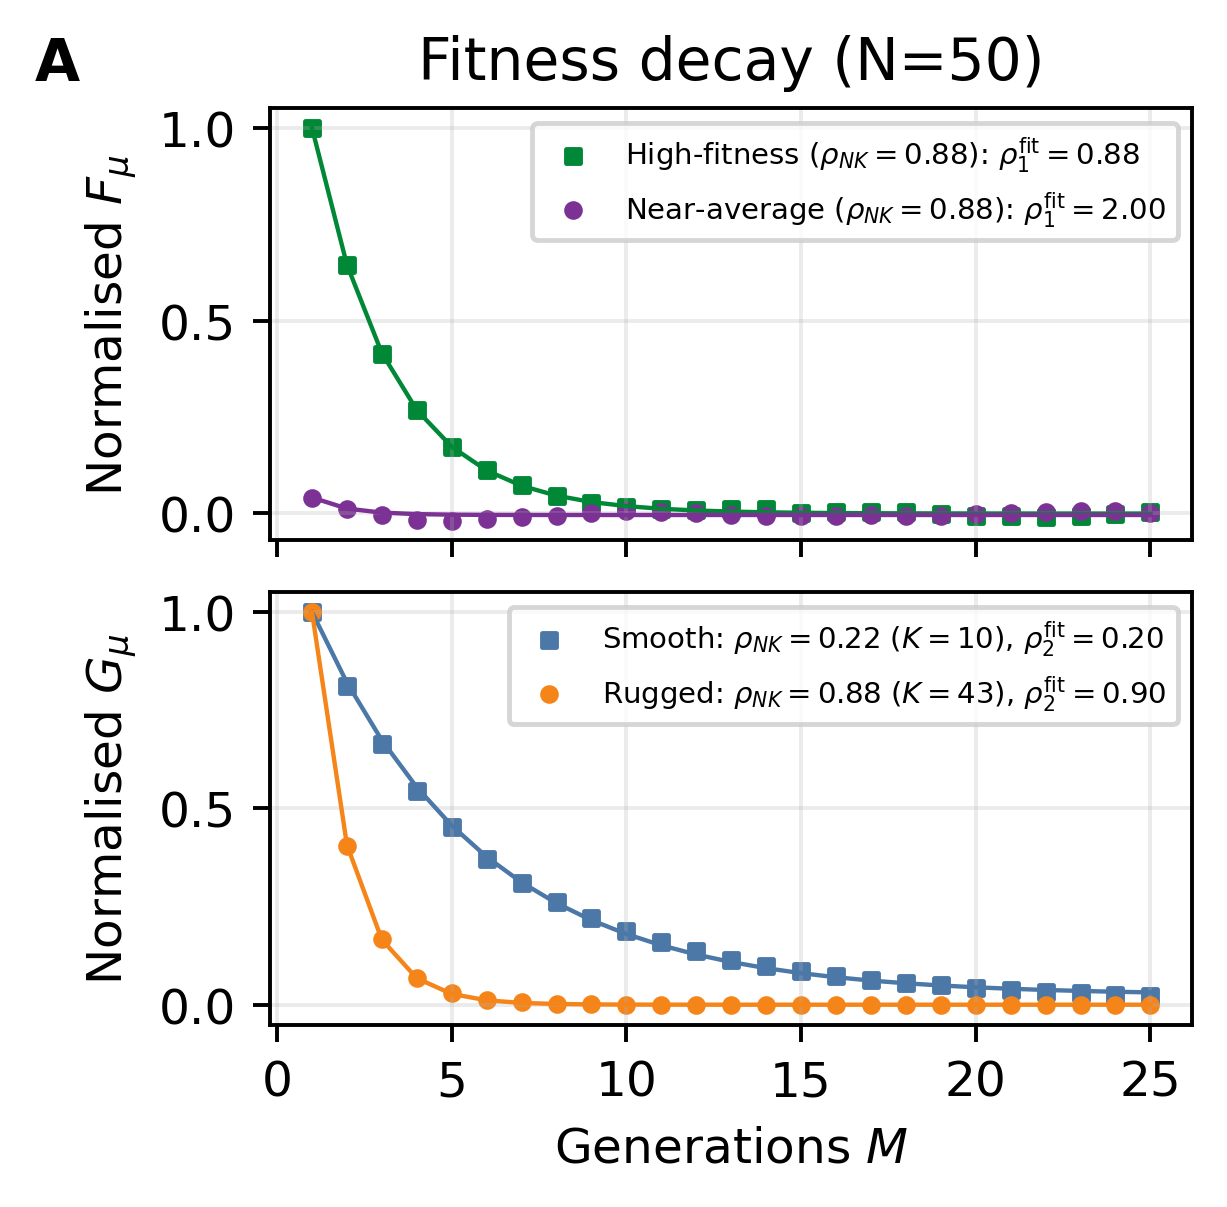

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


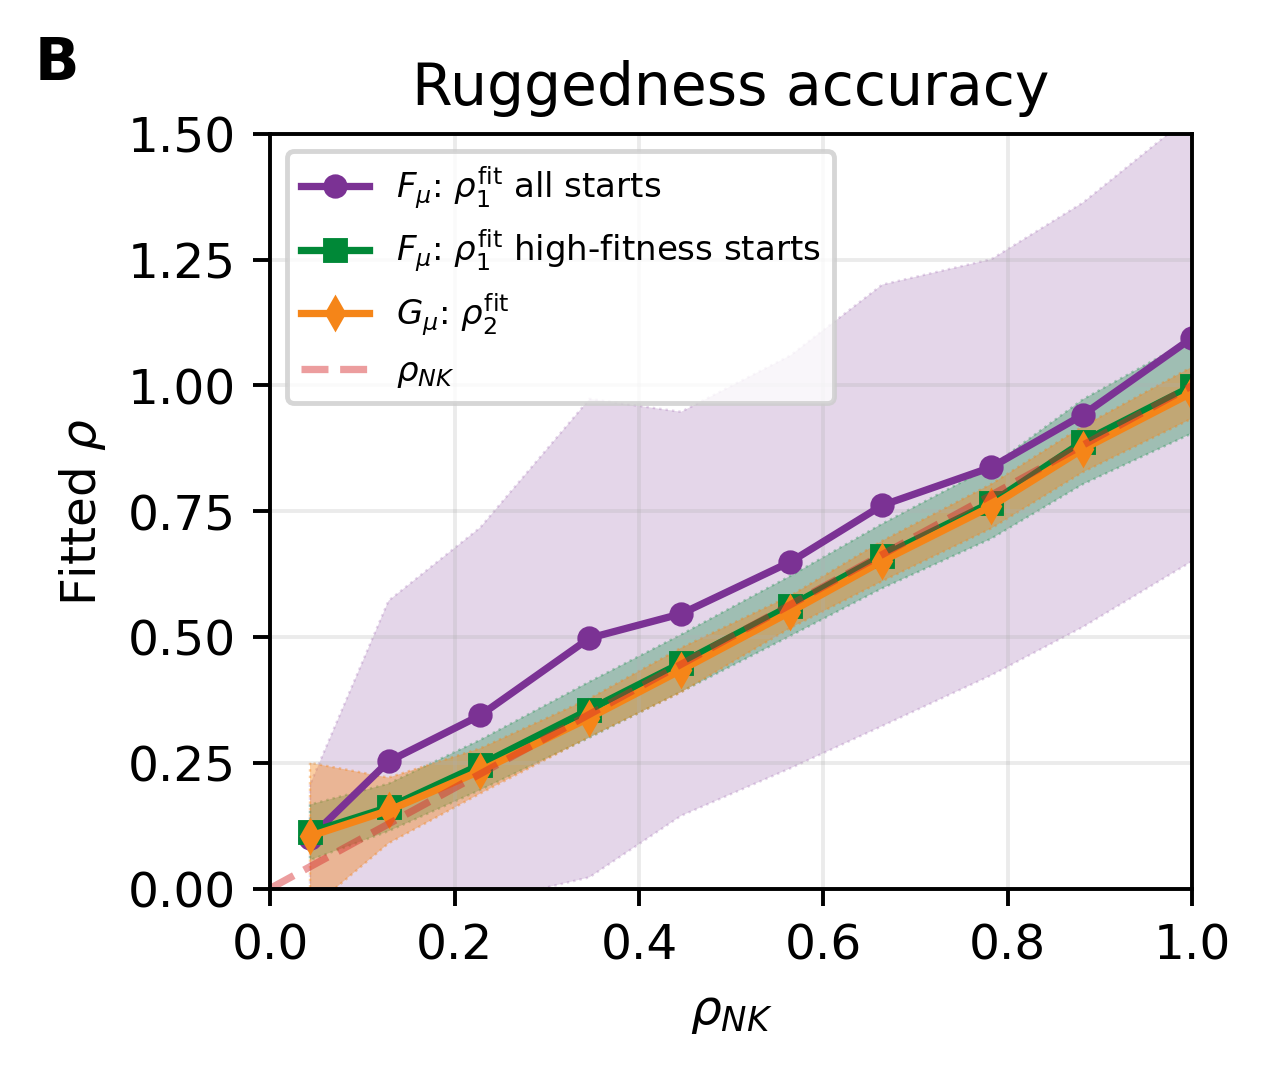

In [27]:
c_decay_smooth = "#4c78a8"
c_decay_rugged = "#f58518"
c_fmu_all = "#7b3294"
c_fmu_high = "#008837"
c_reference = "#d62728"

# Standalone Panel A: F_mu and G_mu decay stacked together.
fig = plt.figure(figsize=(3.4, 3.4), dpi=PANEL_DPI)
gs = fig.add_gridspec(2, 1, hspace=0.12)

ax = fig.add_subplot(gs[0, 0])
for name, curve, colour, label_prefix, mstyle in [
    ("high_start", fmu_examples["high_start"], c_fmu_high, "High-fitness", "s"),
    ("average_start", fmu_examples["average_start"], c_fmu_all, "Near-average", "o"),
]:
    normalized_curve = curve / high_fitness_normalizer
    rho_1_fit, fitted_constant = fmu_example_fits[name]
    rho_NK = (PANEL_A_FMU_PAIR[1]+1) / PANEL_A_FMU_PAIR[0]
    ax.scatter(
        fmu_generations,
        normalized_curve,
        marker=mstyle,
        color=colour,
        s=8,
        label=rf"{label_prefix} ($\rho_{{NK}}={rho_NK:.2f}$): $\rho_1^{{\mathrm{{fit}}}}={rho_1_fit:.2f}$",
    )
    ax.plot(
        fmu_generations,
        model_function(np.arange(len(fmu_generations)), rho_1_fit, fitted_constant, mut=mutation_rate) * curve[0] / high_fitness_normalizer,
        color=colour,
        linewidth=0.9,
    )
ax.set_title(f"Fitness decay (N={PANEL_A_FMU_PAIR[0]})")
ax.set_ylabel(r"Normalised $F_\mu$")
ax.tick_params(labelbottom=False)
ax.legend(frameon=True, fontsize=6)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "A")

ax = fig.add_subplot(gs[1, 0])
for curve, fitted_line, label, colour, mstyle in zip(
    decay_examples["smooth_rugged"],
    decay_examples["fitted_lines"],
    decay_examples["labels"],
    [c_decay_smooth, c_decay_rugged],
    ["s", "o"],
):
    ax.scatter(decay_examples["generations"], curve, label=label, color=colour, s=8, marker=mstyle)
    ax.plot(decay_examples["generations"], fitted_line, color=colour, linewidth=0.9)
ax.set_xlabel(r"Generations $M$")
ax.set_ylabel(r"Normalised $G_\mu$")
ax.legend(frameon=True, fontsize=6)
ax.grid(True, alpha=0.25)
save_panel_figure(fig, "figure_3_A")
plt.show()

# Standalone Panel B: merged G_mu and F_mu ruggedness accuracy.
fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
ax.plot(binned_fmu_rho_NK, binned_rho_1_all_mean, "o-", markersize=4, color=c_fmu_all, label=r"$F_\mu$: $\rho_1^{{\mathrm{fit}}}$ all starts")
ax.fill_between(
    binned_fmu_rho_NK,
    binned_rho_1_all_mean - binned_rho_1_all_std,
    binned_rho_1_all_mean + binned_rho_1_all_std,
    color=c_fmu_all,
    alpha=0.2,
    edgecolor=c_fmu_all,
    linewidth=0.5,
    linestyle=":",
)
ax.plot(binned_fmu_rho_NK, binned_rho_1_high_mean, "s-", markersize=4, color=c_fmu_high, label=r"$F_\mu$: $\rho_1^{{\mathrm{fit}}}$ high-fitness starts")
ax.fill_between(
    binned_fmu_rho_NK,
    binned_rho_1_high_mean - binned_rho_1_high_std,
    binned_rho_1_high_mean + binned_rho_1_high_std,
    color=c_fmu_high,
    alpha=0.3,    
    edgecolor=c_fmu_high,
    linewidth=0.5,
    linestyle=":",
)
ax.plot(
    ruggedness_accuracy_processed["binned_rho_NK"],
    ruggedness_accuracy_processed["binned_rho_2_fit_mean"],
    "d-",
    markersize=4,
    label=r"$G_\mu$: $\rho_2^{{\mathrm{fit}}}$",
    color=c_decay_rugged,
)
ax.fill_between(
    ruggedness_accuracy_processed["binned_rho_NK"],
    ruggedness_accuracy_processed["binned_rho_2_fit_mean"] - ruggedness_accuracy_processed["binned_rho_2_fit_std"],
    ruggedness_accuracy_processed["binned_rho_2_fit_mean"] + ruggedness_accuracy_processed["binned_rho_2_fit_std"],
    alpha=0.4,
    linewidth=0.5,
    linestyle=":",
    color=c_decay_rugged,
)
ax.plot([0, 1], [0, 1], color=c_reference, alpha=0.45, linestyle="--", label=r"$\rho_{NK}$")
ax.set_title("Ruggedness accuracy")
ax.set_xlabel(r"$\rho_{NK}$")
ax.set_ylabel(r"Fitted $\rho$")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.5)
ax.legend(frameon=True, fontsize=7)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "B")
save_panel_figure(fig, "figure_3_B")
plt.show()


In [28]:
METRIC_N_SITES = 12
METRIC_NUM_ALLELES = 2
METRIC_K_VALUES = np.arange(METRIC_N_SITES, dtype=int)
METRIC_NUM_LANDSCAPES = 50
METRIC_SEED = 42
metric_shape = (METRIC_NUM_ALLELES,) * METRIC_N_SITES
metric_rng_keys = jr.split(jr.PRNGKey(METRIC_SEED), METRIC_NUM_LANDSCAPES)
metric_start = np.zeros(METRIC_N_SITES, dtype=int)
metric_rho_NK = (METRIC_K_VALUES + 1) / METRIC_N_SITES

savepath_metric_comparison_payload = processed_path("metric_comparison")
if savepath_metric_comparison_payload.exists() and (PLOT_ONLY or not OVERWRITE_PROCESSED_PKL):
    print(f"{savepath_metric_comparison_payload} already exists. Loading existing processed payload.")
    metric_comparison_payload = load_pickle(savepath_metric_comparison_payload)
    metric_comparison_processed = metric_comparison_payload["data"]
elif PLOT_ONLY:
    raise FileNotFoundError(f"PLOT_ONLY=True requires processed payload {savepath_metric_comparison_payload}")
else:
    metric_roughness_to_slope = np.zeros((len(METRIC_K_VALUES), METRIC_NUM_LANDSCAPES), dtype=float)
    metric_fourier_r2 = np.zeros_like(metric_roughness_to_slope)
    metric_paths_to_max = np.zeros_like(metric_roughness_to_slope)
    metric_closest_max = np.zeros_like(metric_roughness_to_slope)
    metric_local_epistasis = np.zeros_like(metric_roughness_to_slope)
    metric_rho_2_dirichlet = np.zeros_like(metric_roughness_to_slope)
    metric_spectral_entropy = np.zeros_like(metric_roughness_to_slope)

    for k_index, K in enumerate(tqdm(METRIC_K_VALUES, desc="Analytical NK metrics")):
        metric_landscapes = jnp.stack([
            get_nk_l_o_shape(
                metric_rng_key,
                METRIC_N_SITES,
                int(K),
                metric_shape,
            )
            for metric_rng_key in metric_rng_keys
        ])
        epistasis_counts = jax.vmap(lambda landscape: local_epistasis(landscape, metric_start))(metric_landscapes)

        metric_roughness_to_slope[k_index] = np.asarray(jax.vmap(roughness_to_slope)(metric_landscapes), dtype=float)
        metric_fourier_r2[k_index] = np.asarray(jax.vmap(landscape_r2)(metric_landscapes), dtype=float)
        metric_paths_to_max[k_index] = np.asarray(
            [
                get_mean_paths_to_max(landscape, norm=False, extra_slack=0)
                for landscape in metric_landscapes
            ],
            dtype=float,
        )
        metric_closest_max[k_index] = np.asarray(
            1 / jax.vmap(find_distance_to_closest_max)(metric_landscapes),
            dtype=float,
        )
        metric_local_epistasis[k_index] = np.asarray(
            epistasis_counts["simple_sign_episasis"] + epistasis_counts["reciprocal_sign_epistasis"],
            dtype=float,
        )
        metric_rho_2_dirichlet[k_index] = np.asarray(
            jax.vmap(get_dirichlet_metric)(metric_landscapes),
            dtype=float,
        )
        metric_spectral_entropy[k_index] = np.asarray(
            jax.vmap(get_spectral_entropy)(metric_landscapes),
            dtype=float,
        )

    rho_2_fit_by_pair = ruggedness_accuracy_processed["rho_2_fit_all"]
    panel_b_rho_values = np.repeat(rho_NK_all, rho_2_fit_by_pair.shape[1])
    panel_b_rho_2_values = rho_2_fit_by_pair.reshape(-1)
    metric_bin_edges = np.concatenate(
        [
            [-np.inf],
            (metric_rho_NK[:-1] + metric_rho_NK[1:]) / 2,
            [np.inf],
        ]
    )
    metric_rho_2_fit_mean = np.zeros_like(metric_rho_NK, dtype=float)
    metric_rho_2_fit_std = np.zeros_like(metric_rho_NK, dtype=float)
    metric_rho_2_fit_counts = np.zeros_like(metric_rho_NK, dtype=int)

    for metric_index in range(len(metric_rho_NK)):
        in_bin = (
            (panel_b_rho_values > metric_bin_edges[metric_index])
            & (panel_b_rho_values <= metric_bin_edges[metric_index + 1])
        )
        metric_rho_2_fit_mean[metric_index] = panel_b_rho_2_values[in_bin].mean()
        metric_rho_2_fit_std[metric_index] = panel_b_rho_2_values[in_bin].std()
        metric_rho_2_fit_counts[metric_index] = int(in_bin.sum())

    metric_comparison_processed = {
        "rho_NK": metric_rho_NK,
        "rho_2_fit_mean": metric_rho_2_fit_mean,
        "rho_2_fit_std": metric_rho_2_fit_std,
        "rho_2_fit_counts": metric_rho_2_fit_counts,
        "rho_2_dirichlet": metric_rho_2_dirichlet.mean(axis=1),
        "spectral_entropy": metric_spectral_entropy.mean(axis=1),
        "roughness_to_slope": metric_roughness_to_slope.mean(axis=1),
        "fourier_r2": metric_fourier_r2.mean(axis=1),
        "paths_to_max": metric_paths_to_max.mean(axis=1),
        "closest_max": metric_closest_max.mean(axis=1),
        "local_epistasis": metric_local_epistasis.mean(axis=1),
    }
    metric_comparison_payload = {
        "params": {
            "N": METRIC_N_SITES,
            "A": METRIC_NUM_ALLELES,
            "K_values": METRIC_K_VALUES,
            "num_landscapes": METRIC_NUM_LANDSCAPES,
            "seed": METRIC_SEED,
        },
        "data": metric_comparison_processed,
    }
    save_pickle(metric_comparison_payload, savepath_metric_comparison_payload)

metric_comparison_processed


/home/idris/workspace_python/SLIDE/processed_data/figure3_metric_comparison_processed.pkl already exists. Loading existing processed payload.


{'rho_NK': array([0.08333333, 0.16666667, 0.25      , 0.33333333, 0.41666667,
        0.5       , 0.58333333, 0.66666667, 0.75      , 0.83333333,
        0.91666667, 1.        ]),
 'rho_2_fit_mean': array([0.1149427 , 0.21261371, 0.22269757, 0.3321331 , 0.423899  ,
        0.50998681, 0.55007636, 0.65092292, 0.75991251, 0.83288944,
        0.88077179, 0.98592794]),
 'rho_2_fit_std': array([0.11350167, 0.0921178 , 0.02473981, 0.03214147, 0.03198591,
        0.07962747, 0.03191274, 0.04008911, 0.04058759, 0.06711244,
        0.04308859, 0.05127503]),
 'rho_2_fit_counts': array([425,  75, 225, 250, 250,  25, 250, 250, 225, 100, 175, 250]),
 'rho_2_dirichlet': array([0.16666667, 0.22031957, 0.29021188, 0.35768654, 0.43324389,
        0.51055431, 0.59164982, 0.67198856, 0.75033063, 0.83491631,
        0.91739845, 1.00185023]),
 'spectral_entropy': array([2.01727508e-13, 2.36925315e-01, 3.93850611e-01, 4.89120177e-01,
        5.63241980e-01, 6.18297548e-01, 6.62770458e-01, 6.99034970e-01,
  

## Processing — Panel F Ruggedness-Metric Comparison

Compare the fitted global squared-decay rate with alternative ruggedness summaries calculated on matched NK landscapes. Each metric is normalised to its plotted range and grouped by $\rho_{NK}$, allowing their response to increasing epistatic interaction to be compared on a common axis.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


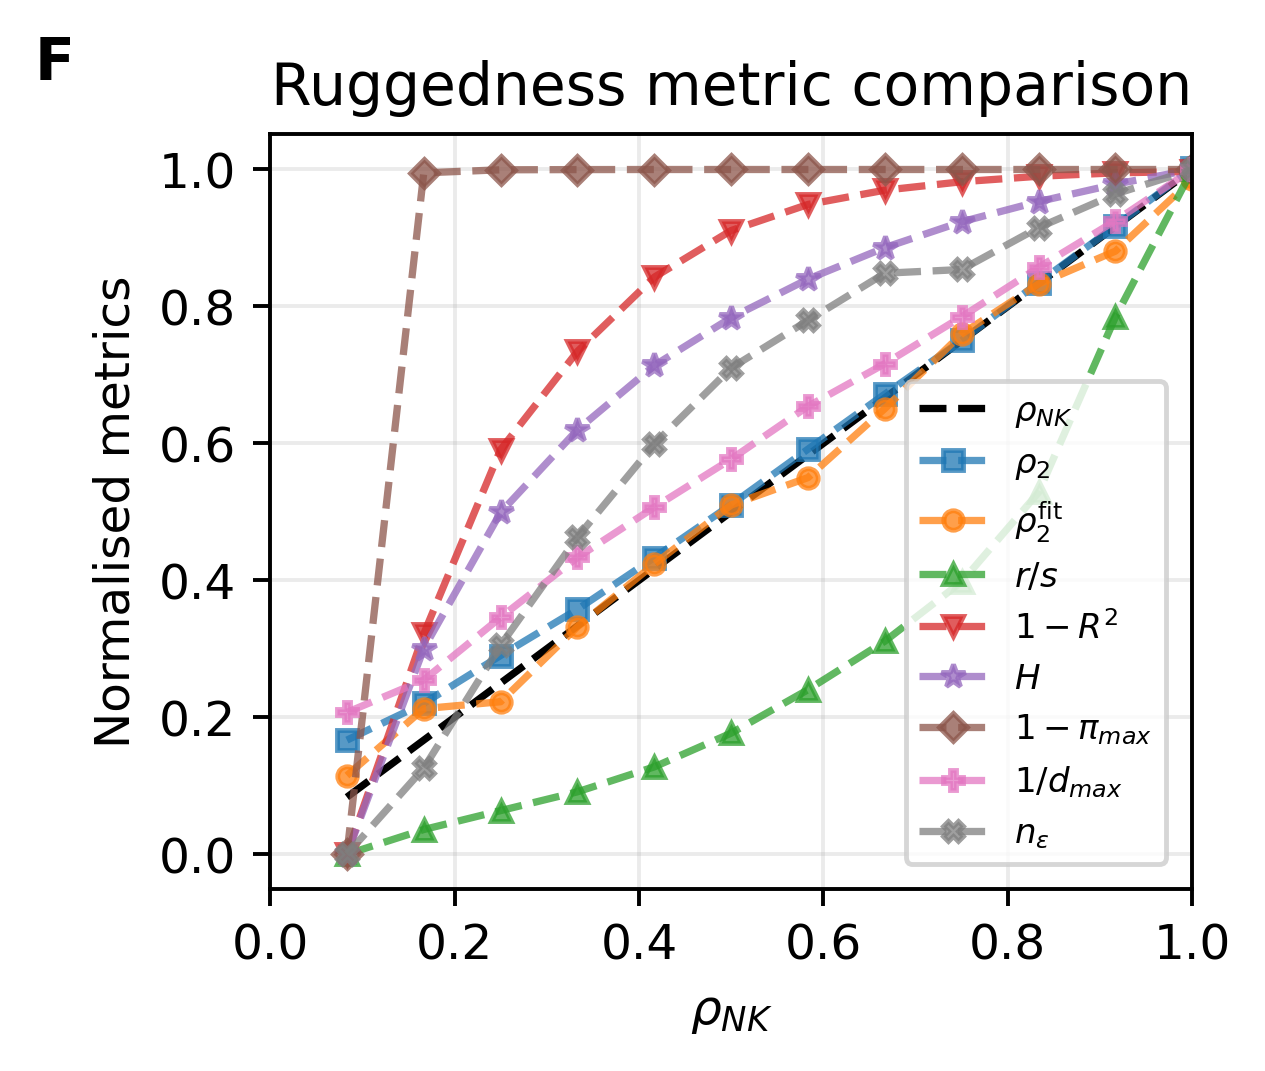

In [29]:
panel_data = metric_comparison_processed
# label_data = {
#     "roughness_to_slope": "Roughness-to-slope ratio",
#     "fourier_r2": r"1 - Landscape $R^2$",
#     "paths_to_max": "1 - Paths to maximum",
#     "closest_max": "Inverse distance to closest local maximum",
#     "local_epistasis": "Local epistasis",
# }
label_data = {
    "roughness_to_slope": r"$r/s$",
    "fourier_r2": r"$1 - R^2$",
    "paths_to_max": r"$1 - \pi_{max}$",
    "closest_max": r"$1/d_{max}$",
    "local_epistasis": r"$n_{\epsilon}$",
    "spectral_entropy": r"$H$",
}
marker_data = {
    "roughness_to_slope": "^",
    "fourier_r2": "v",
    "paths_to_max": "D",
    "closest_max": "P",
    "local_epistasis": "X",
    "spectral_entropy": "*",
}
fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
rho_axis = np.asarray(panel_data["rho_NK"], dtype=float)
rho_2_fit = np.asarray(panel_data["rho_2_fit_mean"], dtype=float)
rho_2_dirichlet = np.asarray(panel_data["rho_2_dirichlet"], dtype=float)



ax.plot(rho_axis, rho_axis, color="black", alpha=1, linestyle="--", label=r"$\rho_{NK}$")
ax.plot(rho_axis, rho_2_dirichlet, "s--", alpha=0.75, markersize=4, label=r"$\rho_2$")
ax.plot(rho_axis, rho_2_fit, "o--", alpha=0.75, markersize=4, label=r"$\rho_2^{{\mathrm{fit}}}$")
ax.plot(
    rho_axis,
    panel_data["roughness_to_slope"] / panel_data["roughness_to_slope"].max(),
    label=label_data["roughness_to_slope"],
    alpha=0.75,
    linestyle="--",
    marker=marker_data["roughness_to_slope"],
    markersize=4,
)
ax.plot(
    rho_axis,
    1 - panel_data["fourier_r2"] / panel_data["fourier_r2"].max(),
    label=label_data["fourier_r2"],
    alpha=0.75,
    linestyle="--",
    marker=marker_data["fourier_r2"],
    markersize=4,
)
ax.plot(
    rho_axis,
    panel_data["spectral_entropy"] / panel_data["spectral_entropy"].max(),
    label=label_data["spectral_entropy"],
    alpha=0.75,
    linestyle="--",
    marker=marker_data["spectral_entropy"],
    markersize=5,
)
ax.plot(
    rho_axis,
    1 - panel_data["paths_to_max"] / panel_data["paths_to_max"].max(),
    label=label_data["paths_to_max"],
    alpha=0.75,
    linestyle="--",
    marker=marker_data["paths_to_max"],
    markersize=4,
)
ax.plot(
    rho_axis,
    panel_data["closest_max"] / panel_data["closest_max"].max(),
    label=label_data["closest_max"],
    alpha=0.75,
    linestyle="--",
    marker=marker_data["closest_max"],
    markersize=4,
)
ax.plot(
    rho_axis,
    panel_data["local_epistasis"] / panel_data["local_epistasis"].max(),
    label=label_data["local_epistasis"],
    alpha=0.75,
    linestyle="--",
    marker=marker_data["local_epistasis"],
    markersize=4,
)
ax.set_title("Ruggedness metric comparison")
ax.set_xlim(0, 1)
ax.set_xlabel(r"$\rho_{NK}$")
ax.set_ylabel("Normalised metrics")
ax.legend(loc="lower right", bbox_to_anchor=(0.99, 0.01), fontsize=7, frameon=True, ncol=1)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "F")
save_panel_figure(fig, "figure_3_F")
plt.show()


## Raw Data and Processing — Panel C Starting-Genotype Sweep

Vary the number of starting genotypes used to estimate global squared-fitness decay while holding the NK model, population size, mutation rate, replicate count, and trajectory length fixed as specified in `start_count_params`. For every landscape and sampled start count, population replicates are averaged within each start, the resulting $F_\mu$ curves are squared, and the selected starts are averaged to form $G_\mu$. Exponential fits quantify how the fitted ruggedness estimate and its variability depend on the number of sampled starts.

In [30]:
start_count_params = {
    "N": 12,
    "K_values": np.array([1, 5, 9], dtype=int),
    "A": 2,
    "num_landscapes": 25,
    "num_reps_per_start": 5,
    "M": 25,
    "seed": 42,
    "start_policy": "random",
    "popsize": 2000,
    "num_starts": np.unique(np.round(np.logspace(0, 3, num=10)).astype(int)),
    "mutation_rate": 0.5,
}
start_count_params["rho_NK"] = (start_count_params["K_values"] + 1) / start_count_params["N"]

start_count_accuracy_path = raw_path("nk_start_count_accuracy")
print_params("Figure 3 new NK starting-point G_mu parameters", start_count_params, start_count_accuracy_path)

start_count_accuracy_payload = None
if PLOT_ONLY:
    print("PLOT_ONLY=True: skipping Figure 3 starting-point raw product loading/building")
elif start_count_accuracy_path.exists() and not OVERWRITE_RAW_PKL:
    loaded_payload = load_pickle(start_count_accuracy_path)
    loaded_params = loaded_payload.get("params", {})
    stale_payload = (
        int(loaded_params.get("N", -1)) != start_count_params["N"]
        or not np.array_equal(np.asarray(loaded_params.get("K_values", []), dtype=int), start_count_params["K_values"])
    )
    if stale_payload:
        print(f"{start_count_accuracy_path} exists but has the old single-K schema. Recomputing raw payload.")
    else:
        print(f"{start_count_accuracy_path} already exists. Loading existing raw payload.")
        start_count_accuracy_payload = loaded_payload

if start_count_accuracy_payload is None and not PLOT_ONLY:
    start_count_key = jr.PRNGKey(start_count_params["seed"])
    start_count_accuracy = np.empty(
        (len(start_count_params["K_values"]), len(start_count_params["num_starts"]), start_count_params["num_landscapes"]),
        dtype=object,
    )

    for k_index, K in enumerate(tqdm(start_count_params["K_values"], desc="Figure 3 new starting-point K")):
        landscape_keys = jr.split(jr.fold_in(start_count_key, int(K)), start_count_params["num_landscapes"])
        for start_count_index, num_starts in enumerate(tqdm(start_count_params["num_starts"], desc=f"K={int(K)} starts", leave=False)):
            for landscape_index, landscape_key in enumerate(landscape_keys):
                start_keys = jr.split(jr.fold_in(landscape_key, 100_000 + landscape_index), int(num_starts))
                starts = np.asarray([
                    random_start(start_key, n_sites=start_count_params["N"], num_alleles=start_count_params["A"])
                    for start_key in start_keys
                ])
                start_count_accuracy[k_index, start_count_index, landscape_index] = np.asarray(
                    run_nk_start_averaged_diffusion(
                        rng_key=landscape_key,
                        n_sites=start_count_params["N"],
                        k=int(K),
                        num_alleles=start_count_params["A"],
                        starts=starts,
                        popsize=start_count_params["popsize"],
                        mutation_rate_per_site=start_count_params["mutation_rate"] / start_count_params["N"],
                        num_reps_per_start=start_count_params["num_reps_per_start"],
                        num_steps=start_count_params["M"],
                    ),
                    dtype=float,
                )

    start_count_accuracy_payload = {
        "data": start_count_accuracy,
        "params": start_count_params,
        "metadata": {
            "description": "Start-resolved multi-K NK starting-point sensitivity sweep for Figure 3 new Panel C.",
            "paper_reference": "Figure 3C",
            "output_key": "figure3_nk_start_count_accuracy",
            "filename": RAW_FILES["nk_start_count_accuracy"],
            "shape": "K, start_count, landscape, start, generation",
        },
    }
    save_pickle(start_count_accuracy_payload, start_count_accuracy_path)

start_count_accuracy_processed_path = processed_path("start_count_accuracy")
start_count_accuracy_processed_payload = None
if start_count_accuracy_processed_path.exists() and (PLOT_ONLY or not OVERWRITE_PROCESSED_PKL):
    loaded_payload = load_pickle(start_count_accuracy_processed_path)
    loaded_params = loaded_payload.get("params", {})
    stale_payload = (
        int(loaded_params.get("N", -1)) != start_count_params["N"]
        or not np.array_equal(np.asarray(loaded_params.get("K_values", []), dtype=int), start_count_params["K_values"])
        or "rho_2_dirichlet_mean" not in loaded_payload.get("data", {})
    )
    if stale_payload and not PLOT_ONLY:
        print(f"{start_count_accuracy_processed_path} exists but has the old schema. Recomputing processed payload.")
    else:
        print(f"{start_count_accuracy_processed_path} already exists. Loading existing processed payload.")
        start_count_accuracy_processed_payload = loaded_payload

if start_count_accuracy_processed_payload is None and PLOT_ONLY:
    raise FileNotFoundError(f"PLOT_ONLY=True requires processed payload {start_count_accuracy_processed_path}")

if start_count_accuracy_processed_payload is None:
    start_count_accuracy_raw = np.asarray(start_count_accuracy_payload["data"], dtype=object)
    start_count_params = start_count_accuracy_payload["params"]
    print(f"Loaded start-count accuracy shape: {start_count_accuracy_raw.shape}")

    start_count_rates = np.zeros(start_count_accuracy_raw.shape[:3], dtype=float)
    for k_index in range(start_count_accuracy_raw.shape[0]):
        for start_count_index in range(start_count_accuracy_raw.shape[1]):
            for landscape_index in range(start_count_accuracy_raw.shape[2]):
                g_mu = start_curves_to_gmu(start_count_accuracy_raw[k_index, start_count_index, landscape_index], average_axis=0)
                start_count_rates[k_index, start_count_index, landscape_index] = fit_gmu_decay(
                    g_mu,
                    mutation_rate=float(start_count_params["mutation_rate"]),
                    num_steps=int(start_count_params["M"]),
                )[0]

    start_count_landscape_shape = (start_count_params["A"],) * start_count_params["N"]
    start_count_key = jr.PRNGKey(start_count_params["seed"])
    start_count_rho_2_dirichlet = np.zeros((len(start_count_params["K_values"]), start_count_params["num_landscapes"]), dtype=float)
    for k_index, K in enumerate(start_count_params["K_values"]):
        landscape_keys = jr.split(jr.fold_in(start_count_key, int(K)), start_count_params["num_landscapes"])
        for landscape_index, landscape_key in enumerate(landscape_keys):
            complete_landscape = get_nk_l_o_shape(landscape_key, start_count_params["N"], int(K), start_count_landscape_shape)
            start_count_rho_2_dirichlet[k_index, landscape_index] = float(get_dirichlet_metric(complete_landscape))

    start_count_processed = {
        "rates": start_count_rates,
        "num_starts": np.asarray(start_count_params["num_starts"], dtype=int),
        "K_values": np.asarray(start_count_params["K_values"], dtype=int),
        "rho_NK": np.asarray(start_count_params["rho_NK"], dtype=float),
        "rho_2_dirichlet_by_landscape": start_count_rho_2_dirichlet,
        "rho_2_dirichlet_mean": start_count_rho_2_dirichlet.mean(axis=1),
        "rho_2_dirichlet_std": start_count_rho_2_dirichlet.std(axis=1),
    }
    start_count_accuracy_processed_payload = {
        "data": start_count_processed,
        "params": start_count_params,
        "metadata": {
            "description": "Processed multi-K NK G_mu starting-point sensitivity for Figure 3 new Panel C.",
            "paper_reference": "Figure 3C",
            "output_key": "figure3_start_count_accuracy",
            "filename": PROCESSED_FILES["start_count_accuracy"],
        },
    }
    save_pickle(start_count_accuracy_processed_payload, start_count_accuracy_processed_path)
else:
    start_count_processed = start_count_accuracy_processed_payload["data"]
    start_count_params = start_count_accuracy_processed_payload["params"]
    start_count_rates = np.asarray(start_count_processed["rates"], dtype=float)

print("Panel C diagnostics:")
for k_index, K in enumerate(start_count_processed["K_values"]):
    print(
        f"  K={int(K)}: rho_NK={start_count_processed['rho_NK'][k_index]:.3f}, "
        f"rho_2={start_count_processed['rho_2_dirichlet_mean'][k_index]:.3f}, "
        f"final rho_2_fit={start_count_rates[k_index, -1].mean():.3f}"
    )



---
Figure 3 new NK starting-point G_mu parameters:
  N: 12
  K_values: [1 5 9]
  A: 2
  num_landscapes: 25
  num_reps_per_start: 5
  M: 25
  seed: 42
  start_policy: random
  popsize: 2000
  num_starts: [   1    2    5   10   22   46  100  215  464 1000]
  mutation_rate: 0.5
  rho_NK: [0.16666667 0.5        0.83333333]
Save path: /home/idris/workspace_python/SLIDE/raw_data/figure3_nk_start_count_accuracy_raw.pkl
---

PLOT_ONLY=True: skipping Figure 3 starting-point raw product loading/building
/home/idris/workspace_python/SLIDE/processed_data/figure3_start_count_accuracy_processed.pkl already exists. Loading existing processed payload.
Panel C diagnostics:
  K=1: rho_NK=0.167, rho_2=0.223, final rho_2_fit=0.222
  K=5: rho_NK=0.500, rho_2=0.512, final rho_2_fit=0.484
  K=9: rho_NK=0.833, rho_2=0.835, final rho_2_fit=0.805


## Raw Data and Processing — Panel D Population-Size Sweep

Vary the simulated population size for three NK ruggedness levels while keeping the remaining parameters in `popsize_params` fixed. Finite populations introduce sampling noise into each replicate mean-fitness trajectory. Processing averages replicates per start, constructs global $G_\mu$, fits the decay rate for each landscape, and summarises the estimates at each population size against the analytical reference.

In [31]:
popsize_params = {
    "N": 12,
    "K_values": np.array([1, 5, 9], dtype=int),
    "A": 2,
    "num_landscapes": 25,
    "num_starts": 25,
    "num_reps_per_start": 5,
    "M": 25,
    "seed": 42,
    "start_policy": "random",
    "pop_sizes": np.logspace(start=1, stop=4, num=10, endpoint=True, dtype=int),
    "mutation_rate": 0.5,
}
popsize_params["rho_NK"] = (popsize_params["K_values"] + 1) / popsize_params["N"]

popsize_accuracy_path = raw_path("nk_popsize_accuracy")
print_params("Figure 3 new NK popsize G_mu parameters", popsize_params, popsize_accuracy_path)

popsize_accuracy_payload = None
if PLOT_ONLY:
    print("PLOT_ONLY=True: skipping Figure 3 popsize raw product loading/building")
elif popsize_accuracy_path.exists() and not OVERWRITE_RAW_PKL:
    loaded_payload = load_pickle(popsize_accuracy_path)
    loaded_params = loaded_payload.get("params", {})
    stale_payload = (
        int(loaded_params.get("N", -1)) != popsize_params["N"]
        or not np.array_equal(np.asarray(loaded_params.get("K_values", []), dtype=int), popsize_params["K_values"])
    )
    if stale_payload:
        print(f"{popsize_accuracy_path} exists but has the old single-K schema. Recomputing raw payload.")
    else:
        print(f"{popsize_accuracy_path} already exists. Loading existing raw payload.")
        popsize_accuracy_payload = loaded_payload

if popsize_accuracy_payload is None and not PLOT_ONLY:
    popsize_key = jr.PRNGKey(popsize_params["seed"])
    popsize_accuracy = []

    for K in tqdm(popsize_params["K_values"], desc="Figure 3 new popsize K"):
        landscape_keys = jr.split(jr.fold_in(popsize_key, int(K)), popsize_params["num_landscapes"])
        k_results = []
        for popsize in tqdm(popsize_params["pop_sizes"], desc=f"K={int(K)} popsize", leave=False):
            pop_results = []
            for landscape_index, landscape_key in enumerate(landscape_keys):
                start_keys = jr.split(jr.fold_in(landscape_key, 200_000 + landscape_index), popsize_params["num_starts"])
                starts = np.asarray([
                    random_start(start_key, n_sites=popsize_params["N"], num_alleles=popsize_params["A"])
                    for start_key in start_keys
                ])
                pop_results.append(
                    run_nk_start_averaged_diffusion(
                        rng_key=landscape_key,
                        n_sites=popsize_params["N"],
                        k=int(K),
                        num_alleles=popsize_params["A"],
                        starts=starts,
                        popsize=int(popsize),
                        mutation_rate_per_site=popsize_params["mutation_rate"] / popsize_params["N"],
                        num_reps_per_start=popsize_params["num_reps_per_start"],
                        num_steps=popsize_params["M"],
                    )
                )
            k_results.append(np.asarray(pop_results))
        popsize_accuracy.append(np.asarray(k_results))

    popsize_accuracy_payload = {
        "data": np.asarray(popsize_accuracy),
        "params": popsize_params,
        "metadata": {
            "description": "Start-resolved multi-K NK population-size sensitivity sweep for Figure 3 new Panel D.",
            "paper_reference": "Figure 3D",
            "output_key": "figure3_nk_popsize_accuracy",
            "filename": RAW_FILES["nk_popsize_accuracy"],
            "shape": "K, popsize, landscape, start, generation",
        },
    }
    save_pickle(popsize_accuracy_payload, popsize_accuracy_path)

popsize_accuracy_processed_path = processed_path("popsize_accuracy")
popsize_accuracy_processed_payload = None
if popsize_accuracy_processed_path.exists() and (PLOT_ONLY or not OVERWRITE_PROCESSED_PKL):
    loaded_payload = load_pickle(popsize_accuracy_processed_path)
    loaded_params = loaded_payload.get("params", {})
    stale_payload = (
        int(loaded_params.get("N", -1)) != popsize_params["N"]
        or not np.array_equal(np.asarray(loaded_params.get("K_values", []), dtype=int), popsize_params["K_values"])
        or "rho_2_dirichlet_mean" not in loaded_payload.get("data", {})
    )
    if stale_payload and not PLOT_ONLY:
        print(f"{popsize_accuracy_processed_path} exists but has the old schema. Recomputing processed payload.")
    else:
        print(f"{popsize_accuracy_processed_path} already exists. Loading existing processed payload.")
        popsize_accuracy_processed_payload = loaded_payload

if popsize_accuracy_processed_payload is None and PLOT_ONLY:
    raise FileNotFoundError(f"PLOT_ONLY=True requires processed payload {popsize_accuracy_processed_path}")

if popsize_accuracy_processed_payload is None:
    popsize_accuracy_raw = np.asarray(popsize_accuracy_payload["data"], dtype=float)
    popsize_params = popsize_accuracy_payload["params"]
    print(f"Loaded popsize accuracy shape: {popsize_accuracy_raw.shape}")

    popsize_rates = np.zeros(popsize_accuracy_raw.shape[:3], dtype=float)
    for k_index in range(popsize_accuracy_raw.shape[0]):
        for pop_index in range(popsize_accuracy_raw.shape[1]):
            for landscape_index in range(popsize_accuracy_raw.shape[2]):
                g_mu = start_curves_to_gmu(popsize_accuracy_raw[k_index, pop_index, landscape_index], average_axis=0)
                popsize_rates[k_index, pop_index, landscape_index] = fit_gmu_decay(
                    g_mu,
                    mutation_rate=float(popsize_params["mutation_rate"]),
                    num_steps=int(popsize_params["M"]),
                )[0]

    popsize_landscape_shape = (popsize_params["A"],) * popsize_params["N"]
    popsize_key = jr.PRNGKey(popsize_params["seed"])
    popsize_rho_2_dirichlet = np.zeros((len(popsize_params["K_values"]), popsize_params["num_landscapes"]), dtype=float)
    for k_index, K in enumerate(popsize_params["K_values"]):
        landscape_keys = jr.split(jr.fold_in(popsize_key, int(K)), popsize_params["num_landscapes"])
        for landscape_index, landscape_key in enumerate(landscape_keys):
            complete_landscape = get_nk_l_o_shape(landscape_key, popsize_params["N"], int(K), popsize_landscape_shape)
            popsize_rho_2_dirichlet[k_index, landscape_index] = float(get_dirichlet_metric(complete_landscape))

    popsize_processed = {
        "rates": popsize_rates,
        "pop_sizes": np.asarray(popsize_params["pop_sizes"], dtype=int),
        "K_values": np.asarray(popsize_params["K_values"], dtype=int),
        "rho_NK": np.asarray(popsize_params["rho_NK"], dtype=float),
        "rho_2_dirichlet_by_landscape": popsize_rho_2_dirichlet,
        "rho_2_dirichlet_mean": popsize_rho_2_dirichlet.mean(axis=1),
        "rho_2_dirichlet_std": popsize_rho_2_dirichlet.std(axis=1),
    }
    popsize_accuracy_processed_payload = {
        "data": popsize_processed,
        "params": popsize_params,
        "metadata": {
            "description": "Processed multi-K NK G_mu population-size sensitivity for Figure 3 new Panel D.",
            "paper_reference": "Figure 3D",
            "output_key": "figure3_popsize_accuracy",
            "filename": PROCESSED_FILES["popsize_accuracy"],
        },
    }
    save_pickle(popsize_accuracy_processed_payload, popsize_accuracy_processed_path)
else:
    popsize_processed = popsize_accuracy_processed_payload["data"]
    popsize_params = popsize_accuracy_processed_payload["params"]
    popsize_rates = np.asarray(popsize_processed["rates"], dtype=float)

print("Panel D diagnostics:")
for k_index, K in enumerate(popsize_processed["K_values"]):
    print(
        f"  K={int(K)}: rho_NK={popsize_processed['rho_NK'][k_index]:.3f}, "
        f"rho_2={popsize_processed['rho_2_dirichlet_mean'][k_index]:.3f}, "
        f"final rho_2_fit={popsize_rates[k_index, -1].mean():.3f}"
    )



---
Figure 3 new NK popsize G_mu parameters:
  N: 12
  K_values: [1 5 9]
  A: 2
  num_landscapes: 25
  num_starts: 25
  num_reps_per_start: 5
  M: 25
  seed: 42
  start_policy: random
  pop_sizes: [   10    21    46   100   215   464  1000  2154  4641 10000]
  mutation_rate: 0.5
  rho_NK: [0.16666667 0.5        0.83333333]
Save path: /home/idris/workspace_python/SLIDE/raw_data/figure3_nk_popsize_accuracy_raw.pkl
---

PLOT_ONLY=True: skipping Figure 3 popsize raw product loading/building
/home/idris/workspace_python/SLIDE/processed_data/figure3_popsize_accuracy_processed.pkl already exists. Loading existing processed payload.
Panel D diagnostics:
  K=1: rho_NK=0.167, rho_2=0.223, final rho_2_fit=0.247
  K=5: rho_NK=0.500, rho_2=0.512, final rho_2_fit=0.498
  K=9: rho_NK=0.833, rho_2=0.835, final rho_2_fit=0.794


## Raw Data and Processing — Panel E Mutation-Rate Sweep

Vary the expected mutations per sequence per generation for three NK ruggedness levels. The simulation converts each total sequence mutation rate to its corresponding per-site probability. For each rate, the code generates start-resolved mutation-only trajectories and processes them by replicate averaging, squaring, start averaging, and exponential fitting. The resulting distributions show how the amount of accumulated mutation affects decay-rate recovery.

In [32]:
mutation_params = {
    "N": 12,
    "K_values": np.array([1, 5, 9], dtype=int),
    "A": 2,
    "num_landscapes": 25,
    "num_starts": 25,
    "num_reps_per_start": 5,
    "M": 25,
    "seed": 42,
    "start_policy": "random",
    "popsize": 2000,
    "mutation_rates": np.linspace(0.01, 2, 25),
}
mutation_params["rho_NK"] = (mutation_params["K_values"] + 1) / mutation_params["N"]

mutation_accuracy_path = raw_path("nk_mutation_accuracy")
print_params("Figure 3 new NK mutation-rate G_mu parameters", mutation_params, mutation_accuracy_path)

mutation_accuracy_payload = None
if PLOT_ONLY:
    print("PLOT_ONLY=True: skipping Figure 3 mutation-rate raw product loading/building")
elif mutation_accuracy_path.exists() and not OVERWRITE_RAW_PKL:
    loaded_payload = load_pickle(mutation_accuracy_path)
    loaded_params = loaded_payload.get("params", {})
    stale_payload = (
        int(loaded_params.get("N", -1)) != mutation_params["N"]
        or not np.array_equal(np.asarray(loaded_params.get("K_values", []), dtype=int), mutation_params["K_values"])
    )
    if stale_payload:
        print(f"{mutation_accuracy_path} exists but has the old single-K schema. Recomputing raw payload.")
    else:
        print(f"{mutation_accuracy_path} already exists. Loading existing raw payload.")
        mutation_accuracy_payload = loaded_payload

if mutation_accuracy_payload is None and not PLOT_ONLY:
    mutation_key = jr.PRNGKey(mutation_params["seed"])
    mutation_accuracy = []

    for K in tqdm(mutation_params["K_values"], desc="Figure 3 new mutation-rate K"):
        landscape_keys = jr.split(jr.fold_in(mutation_key, int(K)), mutation_params["num_landscapes"])
        k_results = []
        for mutation_rate_value in tqdm(mutation_params["mutation_rates"], desc=f"K={int(K)} mutation", leave=False):
            mutation_results = []
            for landscape_index, landscape_key in enumerate(landscape_keys):
                start_keys = jr.split(jr.fold_in(landscape_key, 300_000 + landscape_index), mutation_params["num_starts"])
                starts = np.asarray([
                    random_start(start_key, n_sites=mutation_params["N"], num_alleles=mutation_params["A"])
                    for start_key in start_keys
                ])
                mutation_results.append(
                    run_nk_start_averaged_diffusion(
                        rng_key=landscape_key,
                        n_sites=mutation_params["N"],
                        k=int(K),
                        num_alleles=mutation_params["A"],
                        starts=starts,
                        popsize=mutation_params["popsize"],
                        mutation_rate_per_site=float(mutation_rate_value) / mutation_params["N"],
                        num_reps_per_start=mutation_params["num_reps_per_start"],
                        num_steps=mutation_params["M"],
                    )
                )
            k_results.append(np.asarray(mutation_results))
        mutation_accuracy.append(np.asarray(k_results))

    mutation_accuracy_payload = {
        "data": np.asarray(mutation_accuracy),
        "params": mutation_params,
        "metadata": {
            "description": "Start-resolved multi-K NK mutation-rate sensitivity sweep for Figure 3 new Panel E.",
            "paper_reference": "Figure 3E",
            "output_key": "figure3_nk_mutation_accuracy",
            "filename": RAW_FILES["nk_mutation_accuracy"],
            "shape": "K, mutation_rate, landscape, start, generation",
        },
    }
    save_pickle(mutation_accuracy_payload, mutation_accuracy_path)

mutation_accuracy_processed_path = processed_path("mutation_accuracy")
mutation_accuracy_processed_payload = None
if mutation_accuracy_processed_path.exists() and (PLOT_ONLY or not OVERWRITE_PROCESSED_PKL):
    loaded_payload = load_pickle(mutation_accuracy_processed_path)
    loaded_params = loaded_payload.get("params", {})
    stale_payload = (
        int(loaded_params.get("N", -1)) != mutation_params["N"]
        or not np.array_equal(np.asarray(loaded_params.get("K_values", []), dtype=int), mutation_params["K_values"])
        or "rho_2_dirichlet_mean" not in loaded_payload.get("data", {})
    )
    if stale_payload and not PLOT_ONLY:
        print(f"{mutation_accuracy_processed_path} exists but has the old schema. Recomputing processed payload.")
    else:
        print(f"{mutation_accuracy_processed_path} already exists. Loading existing processed payload.")
        mutation_accuracy_processed_payload = loaded_payload

if mutation_accuracy_processed_payload is None and PLOT_ONLY:
    raise FileNotFoundError(f"PLOT_ONLY=True requires processed payload {mutation_accuracy_processed_path}")

if mutation_accuracy_processed_payload is None:
    mutation_accuracy_raw = np.asarray(mutation_accuracy_payload["data"], dtype=float)
    mutation_params = mutation_accuracy_payload["params"]
    print(f"Loaded mutation accuracy shape: {mutation_accuracy_raw.shape}")

    mutation_rates = np.asarray(mutation_params["mutation_rates"], dtype=float)
    mutation_fit_rates = np.zeros(mutation_accuracy_raw.shape[:3], dtype=float)
    for k_index in range(mutation_accuracy_raw.shape[0]):
        for mut_index, mutation_rate_value in enumerate(mutation_rates):
            for landscape_index in range(mutation_accuracy_raw.shape[2]):
                g_mu = start_curves_to_gmu(mutation_accuracy_raw[k_index, mut_index, landscape_index], average_axis=0)
                mutation_fit_rates[k_index, mut_index, landscape_index] = fit_gmu_decay(
                    g_mu,
                    mutation_rate=float(mutation_rate_value),
                    num_steps=int(mutation_params["M"]),
                )[0]

    mutation_landscape_shape = (mutation_params["A"],) * mutation_params["N"]
    mutation_key = jr.PRNGKey(mutation_params["seed"])
    mutation_rho_2_dirichlet = np.zeros((len(mutation_params["K_values"]), mutation_params["num_landscapes"]), dtype=float)
    for k_index, K in enumerate(mutation_params["K_values"]):
        landscape_keys = jr.split(jr.fold_in(mutation_key, int(K)), mutation_params["num_landscapes"])
        for landscape_index, landscape_key in enumerate(landscape_keys):
            complete_landscape = get_nk_l_o_shape(landscape_key, mutation_params["N"], int(K), mutation_landscape_shape)
            mutation_rho_2_dirichlet[k_index, landscape_index] = float(get_dirichlet_metric(complete_landscape))

    mutation_processed = {
        "rates": mutation_fit_rates,
        "mutation_rates": mutation_rates,
        "K_values": np.asarray(mutation_params["K_values"], dtype=int),
        "rho_NK": np.asarray(mutation_params["rho_NK"], dtype=float),
        "rho_2_dirichlet_by_landscape": mutation_rho_2_dirichlet,
        "rho_2_dirichlet_mean": mutation_rho_2_dirichlet.mean(axis=1),
        "rho_2_dirichlet_std": mutation_rho_2_dirichlet.std(axis=1),
    }
    mutation_accuracy_processed_payload = {
        "data": mutation_processed,
        "params": mutation_params,
        "metadata": {
            "description": "Processed multi-K NK G_mu mutation-rate sensitivity for Figure 3 new Panel E.",
            "paper_reference": "Figure 3E",
            "output_key": "figure3_mutation_accuracy",
            "filename": PROCESSED_FILES["mutation_accuracy"],
        },
    }
    save_pickle(mutation_accuracy_processed_payload, mutation_accuracy_processed_path)
else:
    mutation_processed = mutation_accuracy_processed_payload["data"]
    mutation_params = mutation_accuracy_processed_payload["params"]
    mutation_fit_rates = np.asarray(mutation_processed["rates"], dtype=float)

mutation_rates = np.asarray(mutation_processed["mutation_rates"], dtype=float)
print("Panel E diagnostics:")
for k_index, K in enumerate(mutation_processed["K_values"]):
    print(
        f"  K={int(K)}: rho_NK={mutation_processed['rho_NK'][k_index]:.3f}, "
        f"rho_2={mutation_processed['rho_2_dirichlet_mean'][k_index]:.3f}, "
        f"final rho_2_fit={mutation_fit_rates[k_index, -1].mean():.3f}"
    )



---
Figure 3 new NK mutation-rate G_mu parameters:
  N: 12
  K_values: [1 5 9]
  A: 2
  num_landscapes: 25
  num_starts: 25
  num_reps_per_start: 5
  M: 25
  seed: 42
  start_policy: random
  popsize: 2000
  mutation_rates: [0.01       0.09291667 0.17583333 0.25875    0.34166667 0.42458333
 0.5075     0.59041667 0.67333333 0.75625    0.83916667 0.92208333
 1.005      1.08791667 1.17083333 1.25375    1.33666667 1.41958333
 1.5025     1.58541667 1.66833333 1.75125    1.83416667 1.91708333
 2.        ]
  rho_NK: [0.16666667 0.5        0.83333333]
Save path: /home/idris/workspace_python/SLIDE/raw_data/figure3_nk_mutation_accuracy_raw.pkl
---

PLOT_ONLY=True: skipping Figure 3 mutation-rate raw product loading/building
/home/idris/workspace_python/SLIDE/processed_data/figure3_mutation_accuracy_processed.pkl already exists. Loading existing processed payload.
Panel E diagnostics:
  K=1: rho_NK=0.167, rho_2=0.223, final rho_2_fit=0.260
  K=5: rho_NK=0.500, rho_2=0.512, final rho_2_fit=0.538


## Individual Panels — Parameter Sensitivity

Plot the starting-genotype, population-size, and mutation-rate sweeps for the selected $K$ values. The panels share fitted-rate limits and include the analytical squared-decay references, so changes in bias and dispersion can be read across the three experimental controls.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


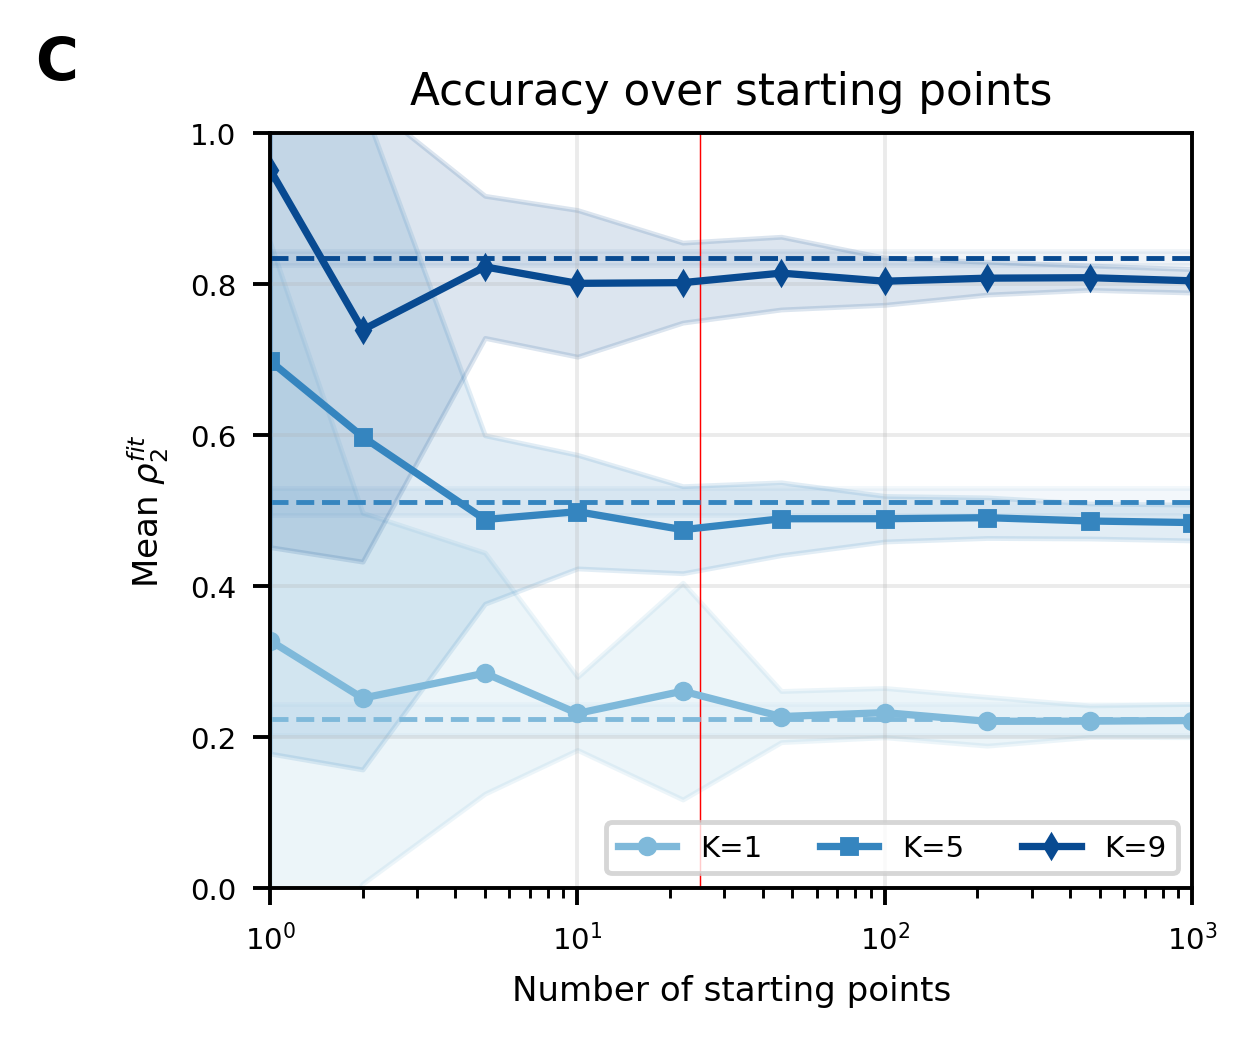

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


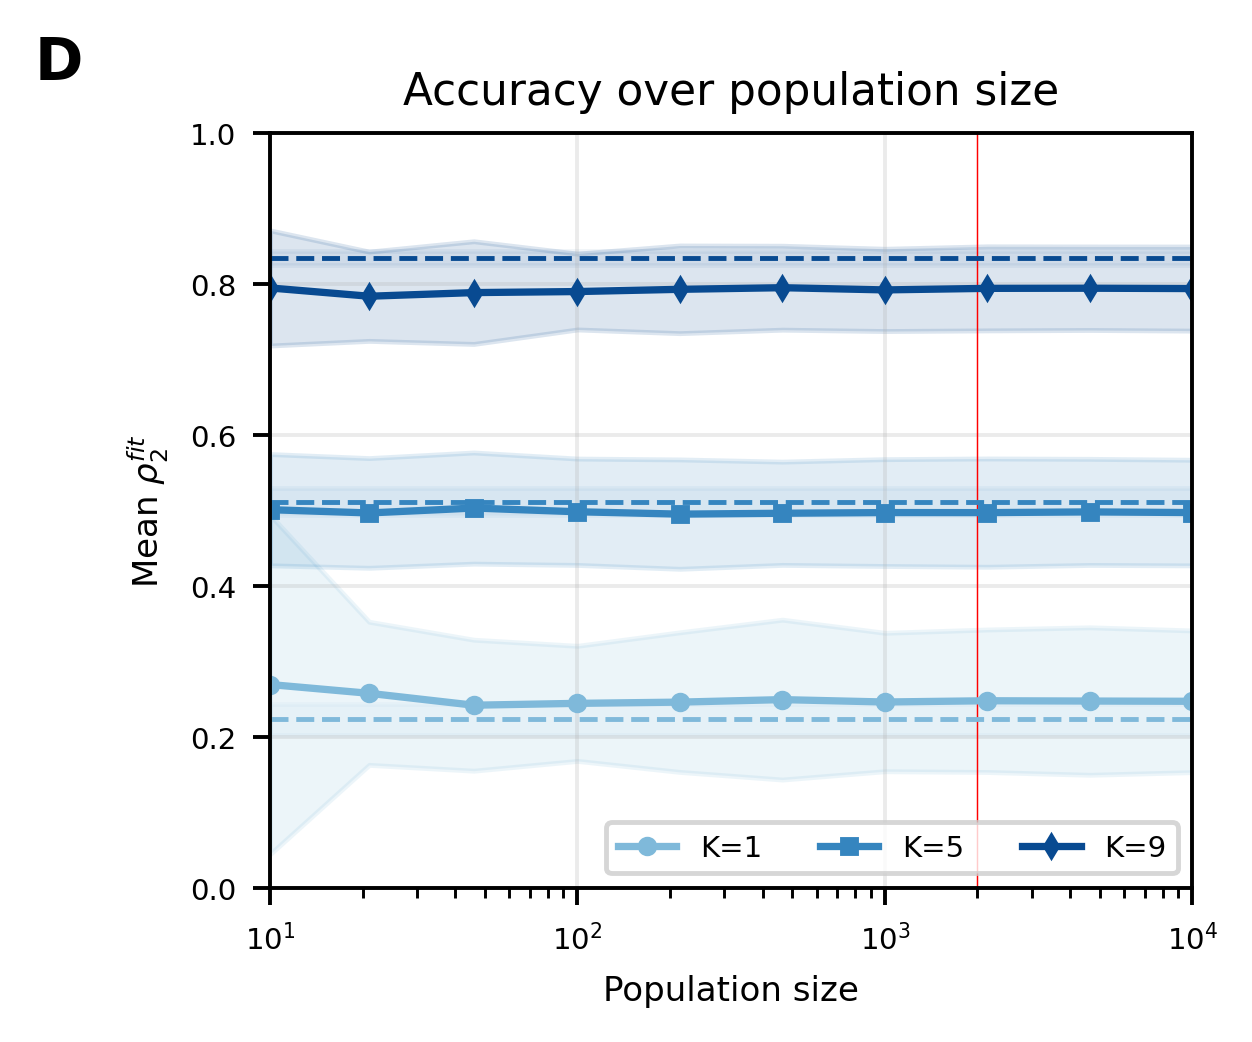

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


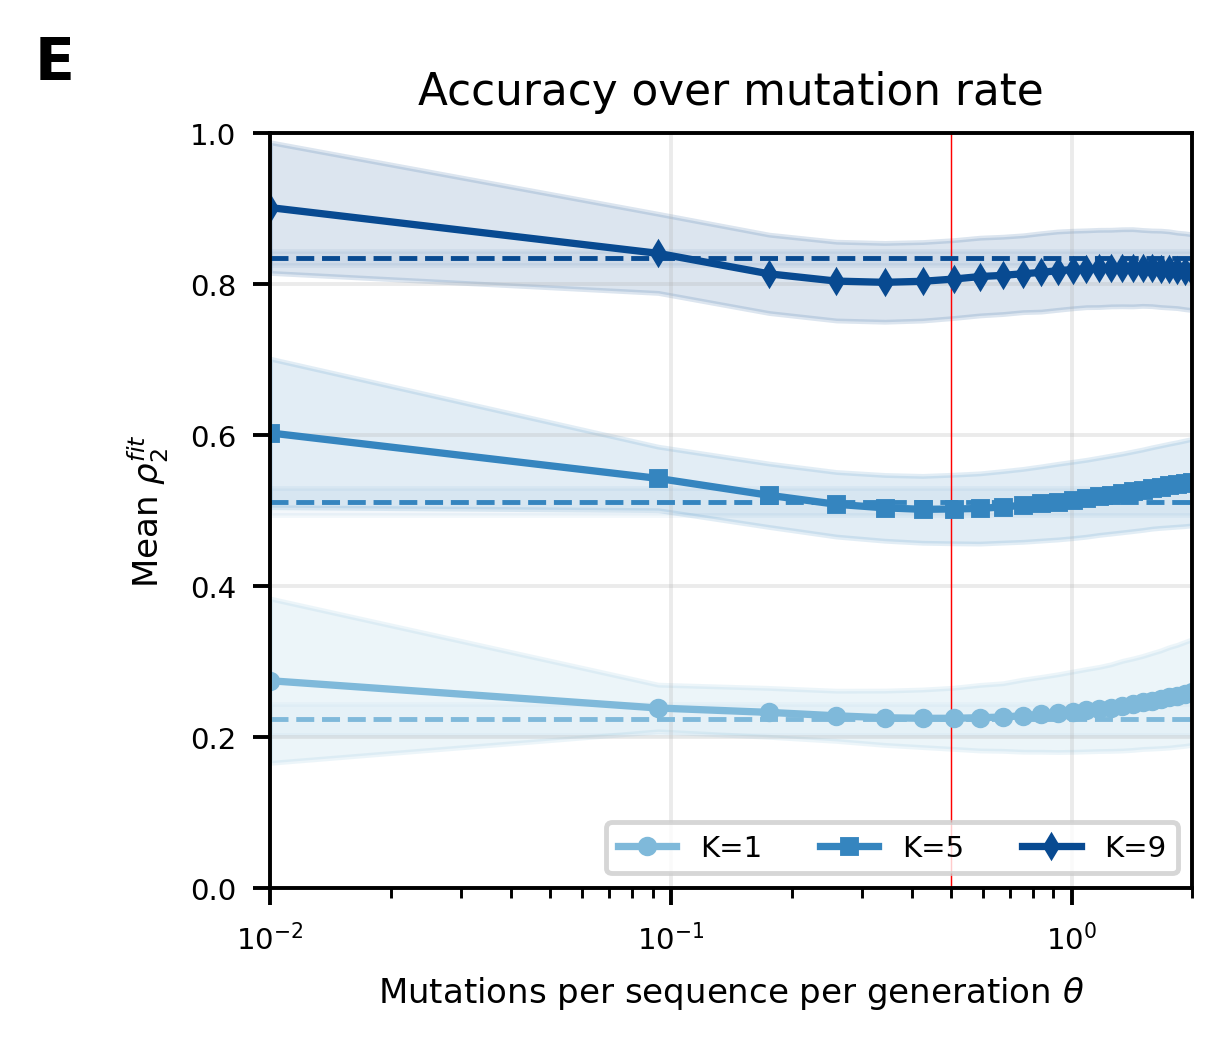

In [33]:
def multik_sensitivity_ylim(processed_panels: list[dict[str, np.ndarray]], rate_arrays: list[np.ndarray]) -> tuple[float, float]:
    """Return shared y-limits for multi-K sensitivity panels.

    Parameters:
    - processed_panels: list[dict[str, np.ndarray]]
        Processed payload data for the sensitivity panels.
    - rate_arrays: list[np.ndarray]
        Fitted rho_2 arrays with shape ``K, sweep, landscape``.

    Returns:
    - tuple[float, float]
        Lower and upper y-limits with a small visual margin.
    """
    y_values = []
    for processed, rates in zip(processed_panels, rate_arrays):
        rate_means = rates.mean(axis=2)
        rate_stds = rates.std(axis=2)
        y_values.extend([rate_means - rate_stds, rate_means + rate_stds])
        rho_2_mean = np.asarray(processed["rho_2_dirichlet_mean"], dtype=float)
        rho_2_std = np.asarray(processed["rho_2_dirichlet_std"], dtype=float)
        y_values.extend([rho_2_mean - rho_2_std, rho_2_mean + rho_2_std])
    y_min = min(float(np.nanmin(values)) for values in y_values)
    y_max = max(float(np.nanmax(values)) for values in y_values)
    margin = 0.05 * max(y_max - y_min, 1e-6)
    return y_min - margin, y_max + margin


def plot_multik_sensitivity(
    ax: plt.Axes,
    processed: dict[str, np.ndarray],
    rates: np.ndarray,
    *,
    x_key: str,
    xlabel: str,
    ylabel: str,
    title: str | None,
    param_text: str,
    ylim: tuple[float, float],
    xlim: tuple[float, float] | None = None,
    xscale: str | None = None,
    legend: bool = True,
    vline: float | None = None,
    titlesize: int = FIGURE_TITLE_SIZE,
    labelsize: int = FIGURE_LABEL_SIZE,
    ticksize: int = FIGURE_TICK_SIZE,
    legendsize: int = FIGURE_LEGEND_SIZE,
    xlabelpad: int = 4,
) -> plt.Axes:
    """Plot fitted and Dirichlet rho_2 sensitivity curves for several K values.

    Parameters:
    - ax: plt.Axes
        Axis to draw on.
    - processed: dict[str, np.ndarray]
        Processed sensitivity data containing sweep axis, K values, and Dirichlet values.
    - rates: np.ndarray
        Fitted rho_2 values with shape ``K, sweep, landscape``.
    - x_key: str
        Key for the sweep axis in ``processed``.
    - xlabel: str
        X-axis label.
    - ylabel: str
        Y-axis label.
    - title: str | None
        Optional axis title.
    - param_text: str
        Text shown in the small parameter box.
    - ylim: tuple[float, float]
        Shared y-limits.
    - xscale: str | None
        Optional x-axis scale, e.g. ``"log"``.
    - legend: bool
        Whether to draw a compact legend.
    - titlesize: int
        Font size for the axis title.
    - labelsize: int
        Font size for axis labels.
    - ticksize: int
        Font size for tick labels.
    - legendsize: int
        Font size for the legend.

    Returns:
    - plt.Axes
        The modified axis.
    """
    x_values = np.asarray(processed[x_key])
    k_values = np.asarray(processed["K_values"], dtype=int)
    colours = plt.cm.Blues(np.linspace(0.45, 0.9, len(k_values)))
    rate_means = rates.mean(axis=2)
    rate_stds = rates.std(axis=2)
    rho_2_mean = np.asarray(processed["rho_2_dirichlet_mean"], dtype=float)
    rho_2_std = np.asarray(processed["rho_2_dirichlet_std"], dtype=float)

    if vline is not None:
        ax.axvline(vline, color="red", linewidth=0.3)
        
    mstyles = ["o-", "s-", "d-"]
    for k_index, K in enumerate(k_values):
        colour = colours[k_index]
        ax.plot(x_values, rate_means[k_index], mstyles[k_index], color=colour, markersize=3, label=rf"K={int(K)}")
        ax.fill_between(
            x_values,
            rate_means[k_index] - rate_stds[k_index],
            rate_means[k_index] + rate_stds[k_index],
            color=colour,
            alpha=0.14,
        )
        ax.axhline(rho_2_mean[k_index], color=colour, linestyle="--", linewidth=1) # , label=rf"K={int(K)} $\rho_2$"
        ax.axhspan(
            rho_2_mean[k_index] - rho_2_std[k_index],
            rho_2_mean[k_index] + rho_2_std[k_index],
            color=colour,
            alpha=0.06,
        )

    if xscale is not None:
        ax.set_xscale(xscale)
    if title is not None:
        ax.set_title(title, fontsize=titlesize)
    if xlim is not None:
        ax.set_xlim(*xlim)
    ax.set_xlabel(xlabel, fontsize=labelsize, labelpad=xlabelpad)
    ax.set_ylabel(ylabel, fontsize=labelsize)
    ax.set_ylim(*ylim)
    ax.tick_params(axis="both", which="major", labelsize=ticksize)
    
    # ax.text(0.03, 0.94, param_text, transform=ax.transAxes, fontsize=labelsize, va="top", bbox=box_style)
    if legend:
        ax.legend(fontsize=legendsize, frameon=True, ncol=3, loc="lower right")
    ax.grid(True, alpha=0.25)
    
    return ax


box_style = FIGURE_BOX_STYLE
start_count_rates = np.asarray(start_count_processed["rates"], dtype=float)
popsize_rates = np.asarray(popsize_processed["rates"], dtype=float)
mutation_fit_rates = np.asarray(mutation_processed["rates"], dtype=float)
sensitivity_ylim = multik_sensitivity_ylim(
    [start_count_processed, popsize_processed, mutation_processed],
    [start_count_rates, popsize_rates, mutation_fit_rates],
)
sensitivity_ylim=(0,1)
k_text = ",".join(str(int(K)) for K in start_count_processed["K_values"])

fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
plot_multik_sensitivity(
    ax,
    start_count_processed,
    start_count_rates,
    x_key="num_starts",
    xlabel="Number of starting points",
    ylabel=r"Mean $\rho_2^{fit}$",
    title="Accuracy over starting points",
    param_text=f"N={start_count_params['N']}, K={k_text}\n$\\theta$={start_count_params['mutation_rate']}, pop={start_count_params['popsize']}",
    ylim=sensitivity_ylim,
    xscale="log",
    vline=25,
    xlim=(1,1000),
)
add_panel_letter(ax, "C")
save_panel_figure(fig, "figure_3_C")
plt.show()

fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
plot_multik_sensitivity(
    ax,
    popsize_processed,
    popsize_rates,
    x_key="pop_sizes",
    xlabel="Population size",
    ylabel=r"Mean $\rho_2^{fit}$",
    title="Accuracy over population size",
    param_text=f"N={popsize_params['N']}, K={k_text}\n$\\theta$={popsize_params['mutation_rate']}, starts={popsize_params['num_starts']}",
    ylim=sensitivity_ylim,
    xscale="log",
    vline=2000,
    xlim=(10,10000),
)
add_panel_letter(ax, "D")
save_panel_figure(fig, "figure_3_D")
plt.show()

fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
plot_multik_sensitivity(
    ax,
    mutation_processed,
    mutation_fit_rates,
    x_key="mutation_rates",
    xlabel=r"Mutations per sequence per generation $\theta$",
    ylabel=r"Mean $\rho_2^{fit}$",
    title="Accuracy over mutation rate",
    param_text=f"N={mutation_params['N']}, K={k_text}\nstarts={mutation_params['num_starts']}, pop={mutation_params['popsize']}",
    ylim=sensitivity_ylim,
    vline=0.5,
    xscale="log",
    xlim=(0.01,2)
    #xlim=(0,2),
)
add_panel_letter(ax, "E")
save_panel_figure(fig, "figure_3_E")
plt.show()


## Complete Figure

Load the processed payloads for all panels and assemble Figure 3. This final cell arranges the local and global decay examples, ruggedness-accuracy results, sampling-sensitivity analyses, and metric comparison without altering the underlying processed values.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


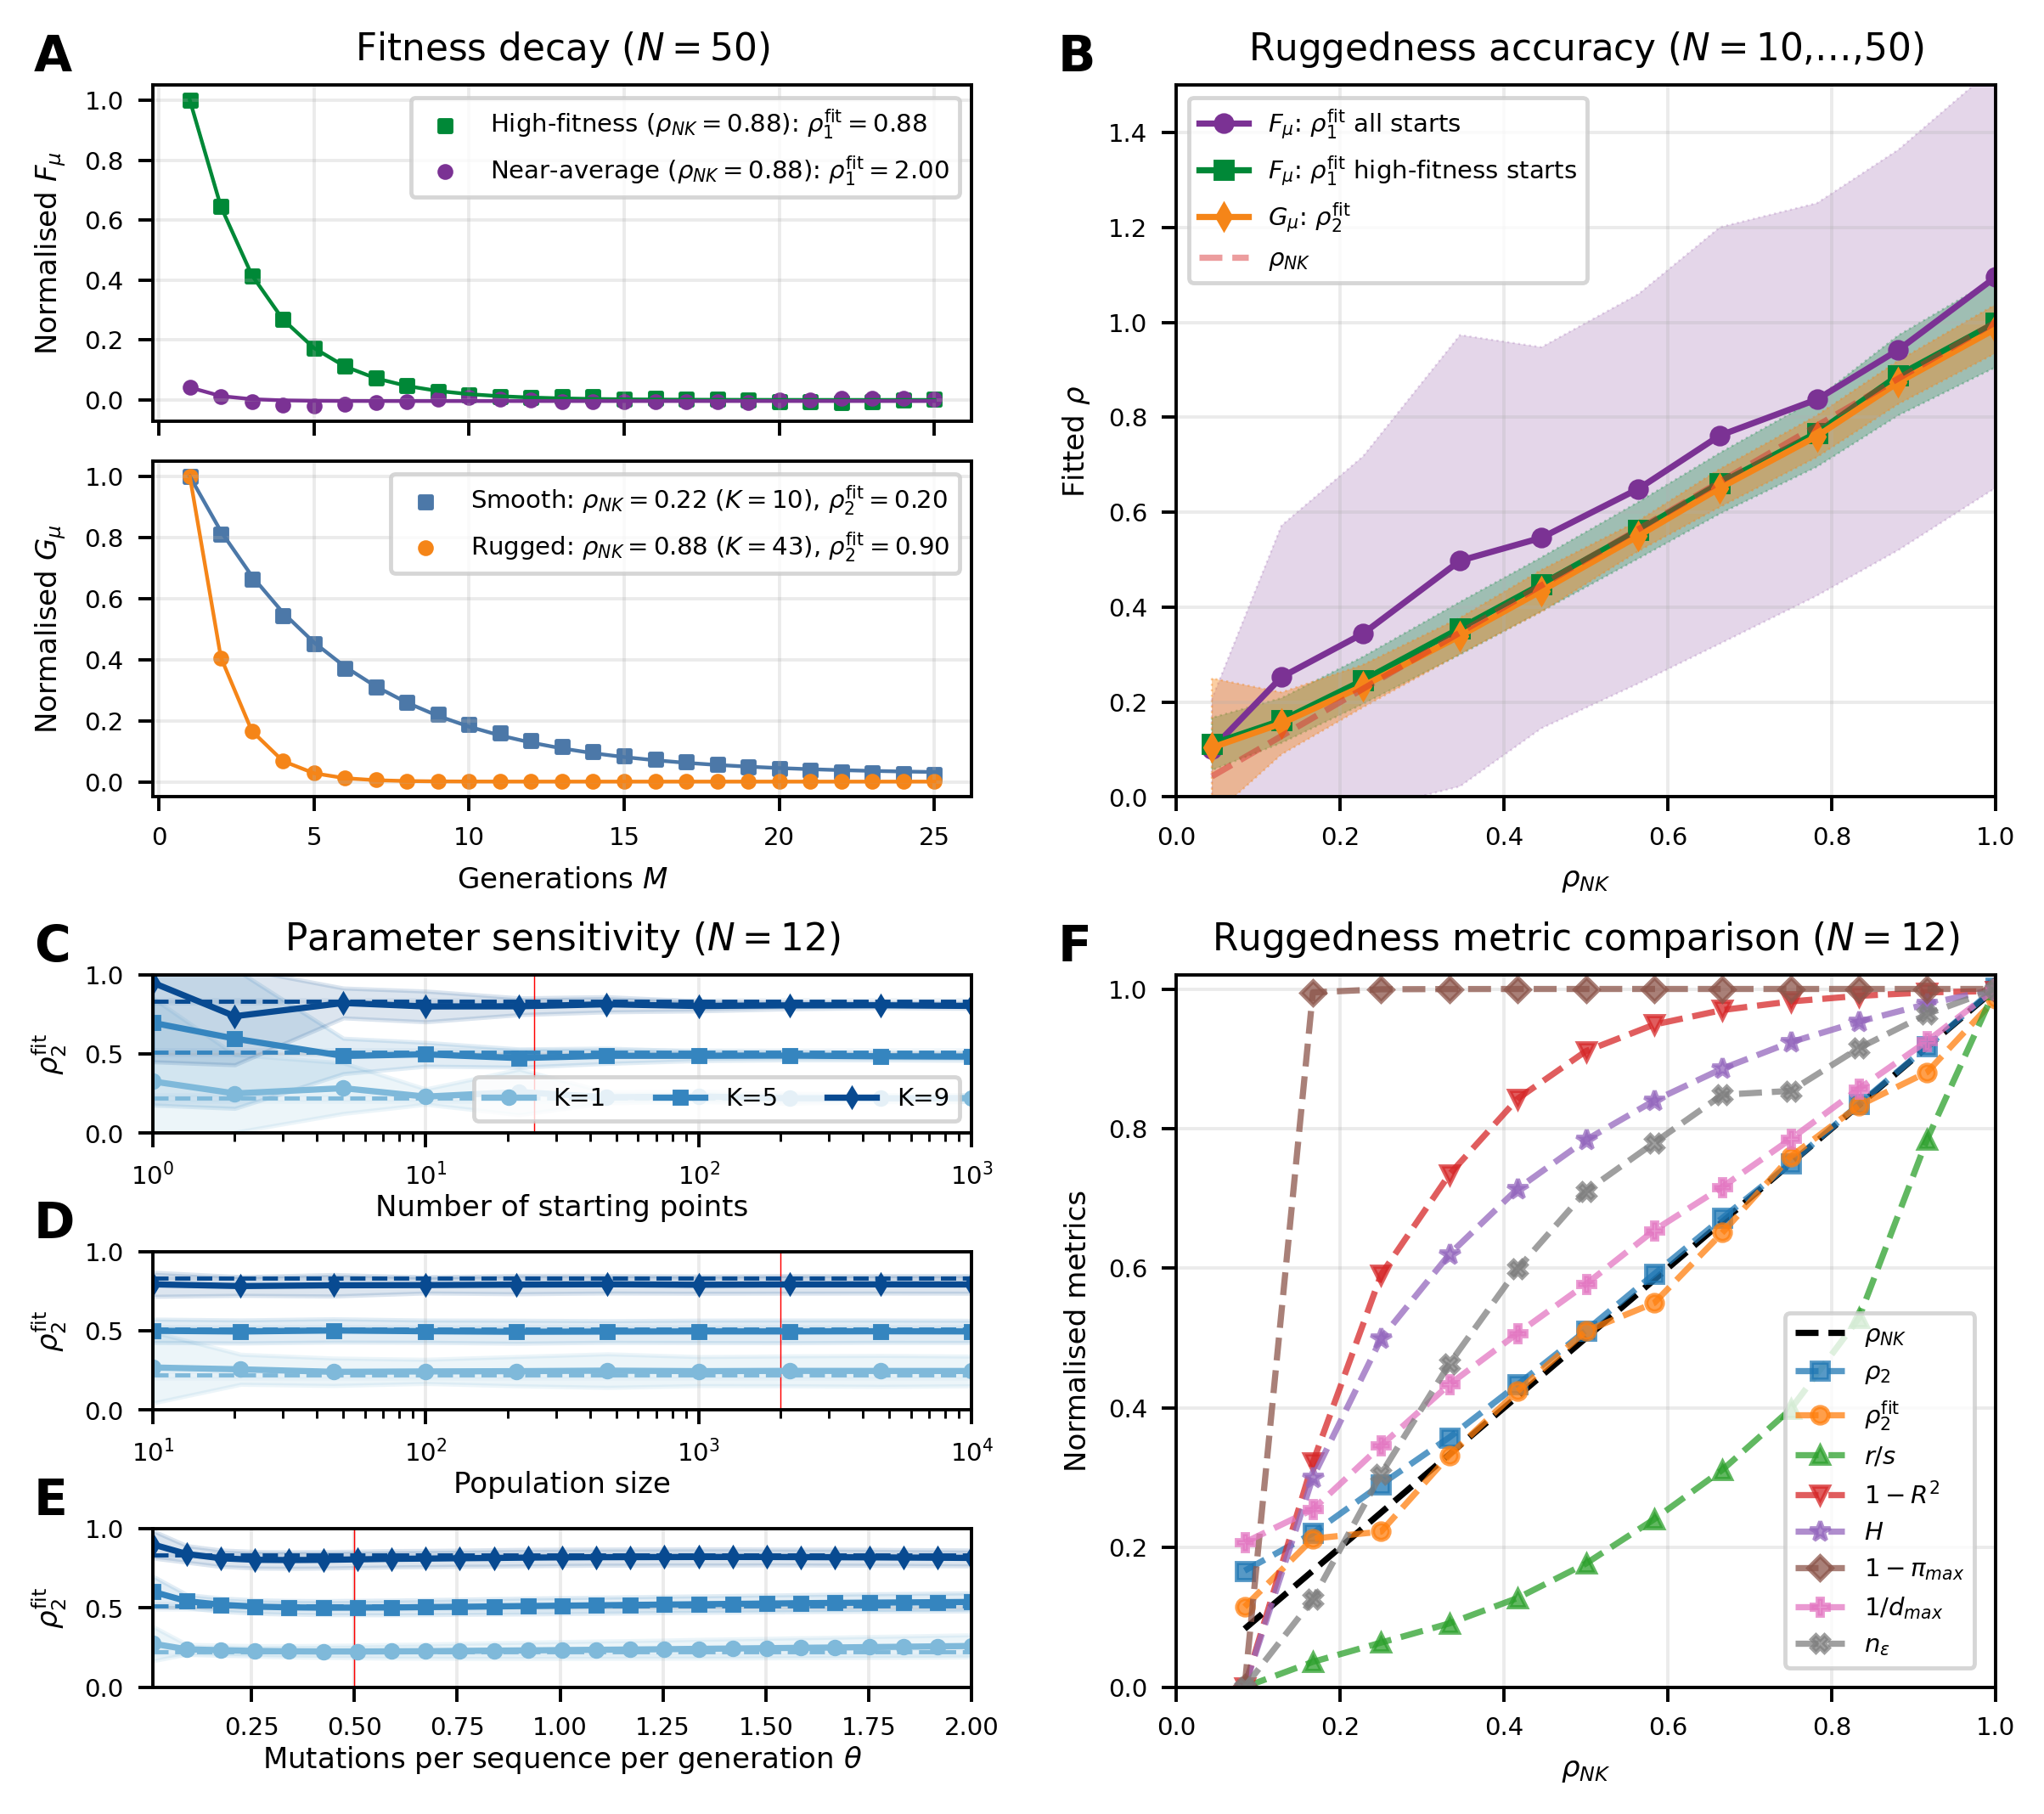

In [ ]:
decay_examples = load_pickle(processed_path("decay_examples"))["data"]
ruggedness_accuracy = load_pickle(processed_path("ruggedness_accuracy"))["data"]
start_count_accuracy_payload = load_pickle(processed_path("start_count_accuracy"))
popsize_accuracy_payload = load_pickle(processed_path("popsize_accuracy"))
mutation_accuracy_payload = load_pickle(processed_path("mutation_accuracy"))
start_count_accuracy_processed = start_count_accuracy_payload["data"]
popsize_accuracy_processed = popsize_accuracy_payload["data"]
mutation_accuracy_processed = mutation_accuracy_payload["data"]
start_count_params = start_count_accuracy_payload["params"]
popsize_params = popsize_accuracy_payload["params"]
mutation_params = mutation_accuracy_payload["params"]
metric_comparison = load_pickle(processed_path("metric_comparison"))["data"]

c_decay_smooth = FIGURE_COLORS["decay_smooth"]
c_decay_rugged = FIGURE_COLORS["decay_rugged"]
c_fmu_all = FIGURE_COLORS["fmu_all"]
c_fmu_high = FIGURE_COLORS["fmu_high"]
c_reference = FIGURE_COLORS["reference"]
labelsize = FIGURE_LABEL_SIZE
titlesize = FIGURE_TITLE_SIZE
legendsize = FIGURE_LEGEND_SIZE
ticksize = FIGURE_TICK_SIZE

box_style = FIGURE_BOX_STYLE

fig = plt.figure(figsize=(8, 7), dpi=PANEL_DPI)
outer = GridSpec(2, 2, figure=fig, height_ratios=[1, 1], width_ratios=[1, 1], hspace=0.25, wspace=0.25)
panel_a_grid = outer[0, 0].subgridspec(2, 1, hspace=0.12)
panel_cde_grid = outer[1, 0].subgridspec(3, 1, hspace=0.75)

# Panel A, top: F_mu decay.
ax = fig.add_subplot(panel_a_grid[0, 0])
for name, curve, colour, label_prefix, mstyle in [
    ("high_start", fmu_examples["high_start"], c_fmu_high, "High-fitness", "s"),
    ("average_start", fmu_examples["average_start"], c_fmu_all, "Near-average", "o"),
]:
    normalized_curve = curve / high_fitness_normalizer
    rho_1_fit, fitted_constant = fmu_example_fits[name]
    rho_NK = (PANEL_A_FMU_PAIR[1]+1) / PANEL_A_FMU_PAIR[0]
    ax.scatter(
        fmu_generations,
        normalized_curve,
        marker=mstyle,
        color=colour,
        s=8,
        label=rf"{label_prefix} ($\rho_{{NK}}={rho_NK:.2f}$): $\rho_1^{{\mathrm{{fit}}}}={rho_1_fit:.2f}$",
    )
    ax.plot(
        fmu_generations,
        model_function(np.arange(len(fmu_generations)), rho_1_fit, fitted_constant, mut=mutation_rate) * curve[0] / high_fitness_normalizer,
        color=colour,
        linewidth=0.9,
    )
ax.set_title(rf"Fitness decay ($N=${PANEL_A_FMU_PAIR[0]})", fontsize=titlesize)
ax.set_ylabel(r"Normalised $F_\mu$", fontsize=labelsize)
ax.tick_params(axis="both", which="major", labelsize=ticksize)
ax.tick_params(labelbottom=False)
ax.legend(fontsize=legendsize, frameon=True, loc="best")
ax.grid(True, alpha=0.25)
panel_letter_offsets = (-0.05, 0.025)
bbox = ax.get_position()
fig.text(bbox.x0 + panel_letter_offsets[0], bbox.y1 + panel_letter_offsets[1], "A", fontsize=PANEL_LETTER_SIZE, fontweight="bold", va="top", ha="left")

# Panel A, bottom: G_mu decay.
ax = fig.add_subplot(panel_a_grid[1, 0])
for curve, fitted_line, label, colour, mstyle in zip(
    decay_examples["smooth_rugged"],
    decay_examples["fitted_lines"],
    decay_examples["labels"],
    [c_decay_smooth, c_decay_rugged],
    ["s", "o"],
):
    ax.scatter(decay_examples["generations"], curve, label=label, color=colour, s=8, marker=mstyle)
    ax.plot(decay_examples["generations"], fitted_line, color=colour, linewidth=0.9)
ax.set_xlabel(r"Generations $M$", fontsize=labelsize)
ax.set_ylabel(r"Normalised $G_\mu$", fontsize=labelsize)
ax.tick_params(axis="both", which="major", labelsize=ticksize)
ax.legend(fontsize=legendsize, frameon=True, loc="best")
ax.grid(True, alpha=0.25)

# Panel B: merged G_mu and F_mu accuracy.
ax = fig.add_subplot(outer[0, 1])
ax.plot(binned_fmu_rho_NK, binned_rho_1_all_mean, "o-", markersize=4, color=c_fmu_all, label=r"$F_\mu$: $\rho_1^{{\mathrm{fit}}}$ all starts")
ax.fill_between(
    binned_fmu_rho_NK,
    binned_rho_1_all_mean - binned_rho_1_all_std,
    binned_rho_1_all_mean + binned_rho_1_all_std,
    color=c_fmu_all,
    alpha=0.2,
    edgecolor=c_fmu_all,
    linewidth=0.5,
    linestyle=":",
)
ax.plot(binned_fmu_rho_NK, binned_rho_1_high_mean, "s-", markersize=4, color=c_fmu_high, label=r"$F_\mu$: $\rho_1^{{\mathrm{fit}}}$ high-fitness starts")
ax.fill_between(
    binned_fmu_rho_NK,
    binned_rho_1_high_mean - binned_rho_1_high_std,
    binned_rho_1_high_mean + binned_rho_1_high_std,
    color=c_fmu_high,
    alpha=0.3,
    edgecolor=c_fmu_high,
    linewidth=0.5,
    linestyle=":",
)
ax.plot(
    ruggedness_accuracy["binned_rho_NK"],
    ruggedness_accuracy["binned_rho_2_fit_mean"],
    "d-",
    markersize=4,
    label=r"$G_\mu$: $\rho_2^{{{\mathrm{fit}}}}$",
    color=c_decay_rugged,
)
ax.fill_between(
    ruggedness_accuracy["binned_rho_NK"],
    ruggedness_accuracy["binned_rho_2_fit_mean"] - ruggedness_accuracy["binned_rho_2_fit_std"],
    ruggedness_accuracy["binned_rho_2_fit_mean"] + ruggedness_accuracy["binned_rho_2_fit_std"],
    alpha=0.4,
    linewidth=0.5,
    linestyle=":",
    color=c_decay_rugged,
)
ax.plot([ruggedness_accuracy["binned_rho_NK"].min(), 1], [ruggedness_accuracy["binned_rho_NK"].min(), 1], color=c_reference, alpha=0.45, linestyle="--", label=r"$\rho_{NK}$")
ax.set_title(rf"Ruggedness accuracy ($N=${grid_params['N_range'][0]},$\ldots$,{grid_params['N_range'][1]})", fontsize=titlesize)
ax.set_xlabel(r"$\rho_{NK}$", fontsize=labelsize)
ax.set_ylabel(r"Fitted $\rho$", fontsize=labelsize)
# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1.5)
ax.tick_params(axis="both", which="major", labelsize=ticksize)
ax.legend(fontsize=legendsize, frameon=True, ncol=1, loc="best")
ax.grid(True, alpha=0.25)
bbox = ax.get_position()
fig.text(bbox.x0 + panel_letter_offsets[0], bbox.y1 + panel_letter_offsets[1], "B", fontsize=PANEL_LETTER_SIZE, fontweight="bold", va="top", ha="left")

# Panels C-E: multi-K sensitivity.
start_count_rates = np.asarray(start_count_accuracy_processed["rates"], dtype=float)
popsize_rates = np.asarray(popsize_accuracy_processed["rates"], dtype=float)
mutation_fit_rates = np.asarray(mutation_accuracy_processed["rates"], dtype=float)
sensitivity_ylim = (0, 1)
k_text = ",".join(str(int(K)) for K in start_count_accuracy_processed["K_values"])

# Panel C: starting-point sensitivity.
assert start_count_params["N"] == popsize_params["N"] == mutation_params["N"]
ax = fig.add_subplot(panel_cde_grid[0, 0])
plot_multik_sensitivity(
    ax,
    start_count_accuracy_processed,
    start_count_rates,
    x_key="num_starts",
    xlabel="Number of starting points",
    ylabel=r"$\rho_2^{{\mathrm{{fit}}}}$",
    title=rf"Parameter sensitivity ($N=${start_count_params['N']})",
    param_text=f"N={start_count_params['N']}, K={k_text}\n$\\theta$={start_count_params['mutation_rate']}, pop={start_count_params['popsize']}",
    ylim=sensitivity_ylim,
    xscale="log",
    legend=True,
    vline=25,
    xlim=(1, 1000),
    titlesize=titlesize,
    labelsize=labelsize,
    ticksize=ticksize,
    legendsize=legendsize,
    xlabelpad=1,
)
bbox = ax.get_position()
fig.text(bbox.x0 + panel_letter_offsets[0], bbox.y1 + panel_letter_offsets[1], "C", fontsize=PANEL_LETTER_SIZE, fontweight="bold", va="top", ha="left")

# Panel D: population-size sensitivity.
ax = fig.add_subplot(panel_cde_grid[1, 0])
plot_multik_sensitivity(
    ax,
    popsize_accuracy_processed,
    popsize_rates,
    x_key="pop_sizes",
    xlabel="Population size",
    ylabel=r"$\rho_2^{{\mathrm{{fit}}}}$",
    title=None, # "Accuracy over population size",
    param_text=f"N={popsize_params['N']}, K={k_text}\n$\\theta$={popsize_params['mutation_rate']}, starts={popsize_params['num_starts']}",
    ylim=sensitivity_ylim,
    xscale="log",
    legend=False,
    vline=2000,
    xlim=(10, 10000),
    titlesize=titlesize,
    labelsize=labelsize,
    ticksize=ticksize,
    legendsize=legendsize,
    xlabelpad=1,
)
bbox = ax.get_position()
fig.text(bbox.x0 + panel_letter_offsets[0], bbox.y1 + panel_letter_offsets[1], "D", fontsize=PANEL_LETTER_SIZE, fontweight="bold", va="top", ha="left")

# Panel E: mutation-rate sensitivity.
ax = fig.add_subplot(panel_cde_grid[2, 0])
plot_multik_sensitivity(
    ax,
    mutation_accuracy_processed,
    mutation_fit_rates,
    x_key="mutation_rates",
    xlabel=r"Mutations per sequence per generation $\theta$",
    ylabel=r"$\rho_2^{{\mathrm{{fit}}}}$",
    title=None, # "Accuracy over mutation rate",
    param_text=f"N={mutation_params['N']}, K={k_text}\nstarts={mutation_params['num_starts']}, pop={mutation_params['popsize']}",
    ylim=sensitivity_ylim,
    legend=False,
    vline=0.5, # xscale="log",
    xlim=(0.01, 2),
    titlesize=titlesize,
    labelsize=labelsize,
    ticksize=ticksize,
    legendsize=legendsize,
    xlabelpad=1,
)
bbox = ax.get_position()
fig.text(bbox.x0 + panel_letter_offsets[0], bbox.y1 + panel_letter_offsets[1], "E", fontsize=PANEL_LETTER_SIZE, fontweight="bold", va="top", ha="left")

# Panel F: metric comparison.
ax = fig.add_subplot(outer[1, 1])
panel_data = metric_comparison
label_data = {
    "roughness_to_slope": r"$r/s$",
    "fourier_r2": r"$1 - R^2$",
    "paths_to_max": r"$1 - \pi_{max}$",
    "closest_max": r"$1/d_{max}$",
    "local_epistasis": r"$n_{\epsilon}$",
    "spectral_entropy": r"$H$",
}
marker_data = {
    "roughness_to_slope": "^",
    "fourier_r2": "v",
    "paths_to_max": "D",
    "closest_max": "P",
    "local_epistasis": "X",
    "spectral_entropy": "*",
}
rho_axis = np.asarray(panel_data["rho_NK"], dtype=float)
rho_2_fit = np.asarray(panel_data["rho_2_fit_mean"], dtype=float)
rho_2_dirichlet = np.asarray(panel_data["rho_2_dirichlet"], dtype=float)
ax.plot(rho_axis, rho_axis, color="black", alpha=1, linestyle="--", label=r"$\rho_{NK}$")
ax.plot(rho_axis, rho_2_dirichlet, "s--", alpha=0.75, markersize=4, label=r"$\rho_2$")
ax.plot(rho_axis, rho_2_fit, "o--", alpha=0.75, markersize=4, label=r"$\rho_2^{{\mathrm{fit}}}$")
ax.plot(rho_axis, panel_data["roughness_to_slope"] / panel_data["roughness_to_slope"].max(), label=label_data["roughness_to_slope"], alpha=0.75, linestyle="--", marker=marker_data["roughness_to_slope"], markersize=4)
ax.plot(rho_axis, 1 - panel_data["fourier_r2"] / panel_data["fourier_r2"].max(), label=label_data["fourier_r2"], alpha=0.75, linestyle="--", marker=marker_data["fourier_r2"], markersize=4)
ax.plot(rho_axis, panel_data["spectral_entropy"] / panel_data["spectral_entropy"].max(), label=label_data["spectral_entropy"], alpha=0.75, linestyle="--", marker=marker_data["spectral_entropy"], markersize=5)
ax.plot(rho_axis, 1 - panel_data["paths_to_max"] / panel_data["paths_to_max"].max(), label=label_data["paths_to_max"], alpha=0.75, linestyle="--", marker=marker_data["paths_to_max"], markersize=4)
ax.plot(rho_axis, panel_data["closest_max"] / panel_data["closest_max"].max(), label=label_data["closest_max"], alpha=0.75, linestyle="--", marker=marker_data["closest_max"], markersize=4)
ax.plot(rho_axis, panel_data["local_epistasis"] / panel_data["local_epistasis"].max(), label=label_data["local_epistasis"], alpha=0.75, linestyle="--", marker=marker_data["local_epistasis"], markersize=4)
ax.set_title(rf"Ruggedness metric comparison ($N=${metric_comparison_payload['params']['N']})", fontsize=titlesize)
# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1.02)
ax.set_xlabel(r"$\rho_{NK}$", fontsize=labelsize)
ax.set_ylabel("Normalised metrics", fontsize=labelsize)
ax.tick_params(axis="both", which="major", labelsize=ticksize)
ax.legend(loc="lower right", bbox_to_anchor=(0.99, 0.01), fontsize=legendsize, frameon=True, ncol=1)
ax.grid(True, alpha=0.25)
bbox = ax.get_position()
fig.text(bbox.x0 + panel_letter_offsets[0], bbox.y1 + panel_letter_offsets[1], "F", fontsize=PANEL_LETTER_SIZE, fontweight="bold", va="top", ha="left")

save_panel_figure(fig, "figure_3")
plt.show()
